# Task 2 — Development Environment Setup & MNIST CNN Smoke Test (Kaggle)


In [1]:
!pip install -q monai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.6 MB/s eta 0:00:0000:01


## 1. Environment check

In [2]:
import torch, numpy as np, pandas as pd, matplotlib, cv2, monai

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device      :", torch.cuda.get_device_name(0))
print("NumPy version   :", np.__version__)
print("Pandas version  :", pd.__version__)
print("OpenCV version  :", cv2.__version__)
print("MONAI version   :", monai.__version__)


PyTorch version : 2.10.0+cpu
CUDA available  : False
NumPy version   : 2.0.2
Pandas version  : 2.3.3
OpenCV version  : 4.13.0
MONAI version   : 1.6.0


## 2. MNIST CNN smoke test

In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_full = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(Subset(train_full, range(2000)), batch_size=64, shuffle=True)
test_loader = DataLoader(Subset(test_full, range(500)), batch_size=64, shuffle=False)

model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

start = time.time()
model.train()
running_loss = 0.0
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * images.size(0)

train_loss = running_loss / len(train_loader.dataset)
print(f"Train loss: {train_loss:.4f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = correct / total
print(f"Test accuracy: {acc*100:.2f}%")
print(f"Elapsed: {time.time()-start:.1f}s on {device}")

if acc > 0.5:
    print("\n✅ SMOKE TEST PASSED")
else:
    print("\n⚠️ Low accuracy — check setup")


Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.49MB/s]


Train loss: 1.4783
Test accuracy: 69.20%
Elapsed: 1.2s on cpu

✅ SMOKE TEST PASSED


## 3. Quick OpenCV + Matplotlib sanity check

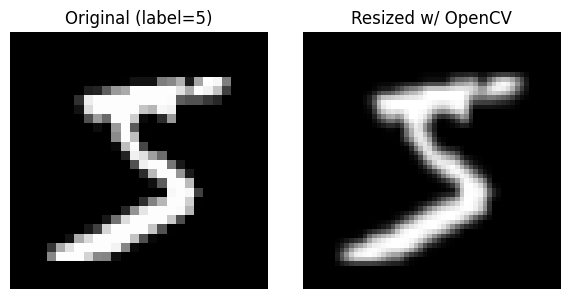

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sample_img, sample_label = train_loader.dataset[0]
img_np = (sample_img.squeeze().numpy() * 0.3081 + 0.1307)
img_np = (img_np * 255).astype(np.uint8)
resized = cv2.resize(img_np, (56, 56), interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_np, cmap="gray"); axes[0].set_title(f"Original (label={sample_label})"); axes[0].axis("off")
axes[1].imshow(resized, cmap="gray"); axes[1].set_title("Resized w/ OpenCV"); axes[1].axis("off")
plt.tight_layout()
plt.show()


# **TASK 03**


In [5]:
!ls /kaggle/input/


datasets


In [8]:
!ls /kaggle/input/datasets/atharzainab/python

01_download_lidc_subset.py  02_explore_lidc.py


In [9]:
!python /kaggle/input/datasets/atharzainab/python/01_download_lidc_subset.py

Installing tcia_utils ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 MB 23.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.5 MB/s eta 0:00:0000:01
Querying series metadata for collection: LIDC-IDRI
2026-08-18 11:21:12,668:INFO:Calling getSeries with parameters {'Collection': 'LIDC-IDRI'}
Total series available in LIDC-IDRI: 15116

Selected 3 series (one per patient) for download:
        PatientID  ... BodyPartExamined
0  LIDC-IDRI-0001  ...            CHEST
1  LIDC-IDRI-0005  ...            CHEST
2  LIDC-IDRI-0007  ...            CHEST

[3 rows x 4 columns]

2026-08-18 11:21:20,108:INFO:Directory './lidc_subset' already exists.
2026-08-18 11:21:20,108:INFO:Found 0 previously downloaded series.
2026-08-18 11:21:20,108:INFO:Attempting to download 3 new series.
2026-08-18 11:21:20

In [10]:
!python /kaggle/input/datasets/atharzainab/python/02_explore_lidc.py


Patient LIDC-IDRI-0005: 133 slices, no annotations found, using mid-scan fallback
  Saved visualization -> ./lidc_exploration_output/LIDC-IDRI-0005_slices.png

Patient LIDC-IDRI-0001: 133 slices, no annotations found, using mid-scan fallback
  Saved visualization -> ./lidc_exploration_output/LIDC-IDRI-0001_slices.png

Patient LIDC-IDRI-0007: 145 slices, no annotations found, using mid-scan fallback
  Saved visualization -> ./lidc_exploration_output/LIDC-IDRI-0007_slices.png

DATASET STATISTICS
Number of patients : 3
Number of scans/series : 3
Slice dimensions seen (rows x cols) : {(512, 512)}
Pixel spacing (mm) — x: min=0.664 max=0.781 mean=0.716
Pixel spacing (mm) — y: min=0.664 max=0.781 mean=0.716
Slice thickness (mm): min=2.500 max=2.500 mean=2.500
Slices per scan: min=133 max=145 mean=137.0

Per-scan detail:
  LIDC-IDRI-0005 | series 1.3.6.1.4.1.1451... | 133 slices | 512x512 | spacing=[0.664062, 0.664062] | thickness=2.5
  LIDC-IDRI-0001 | series 1.3.6.1.4.1.1451... | 133 slices

./lidc_exploration_output/LIDC-IDRI-0001_slices.png


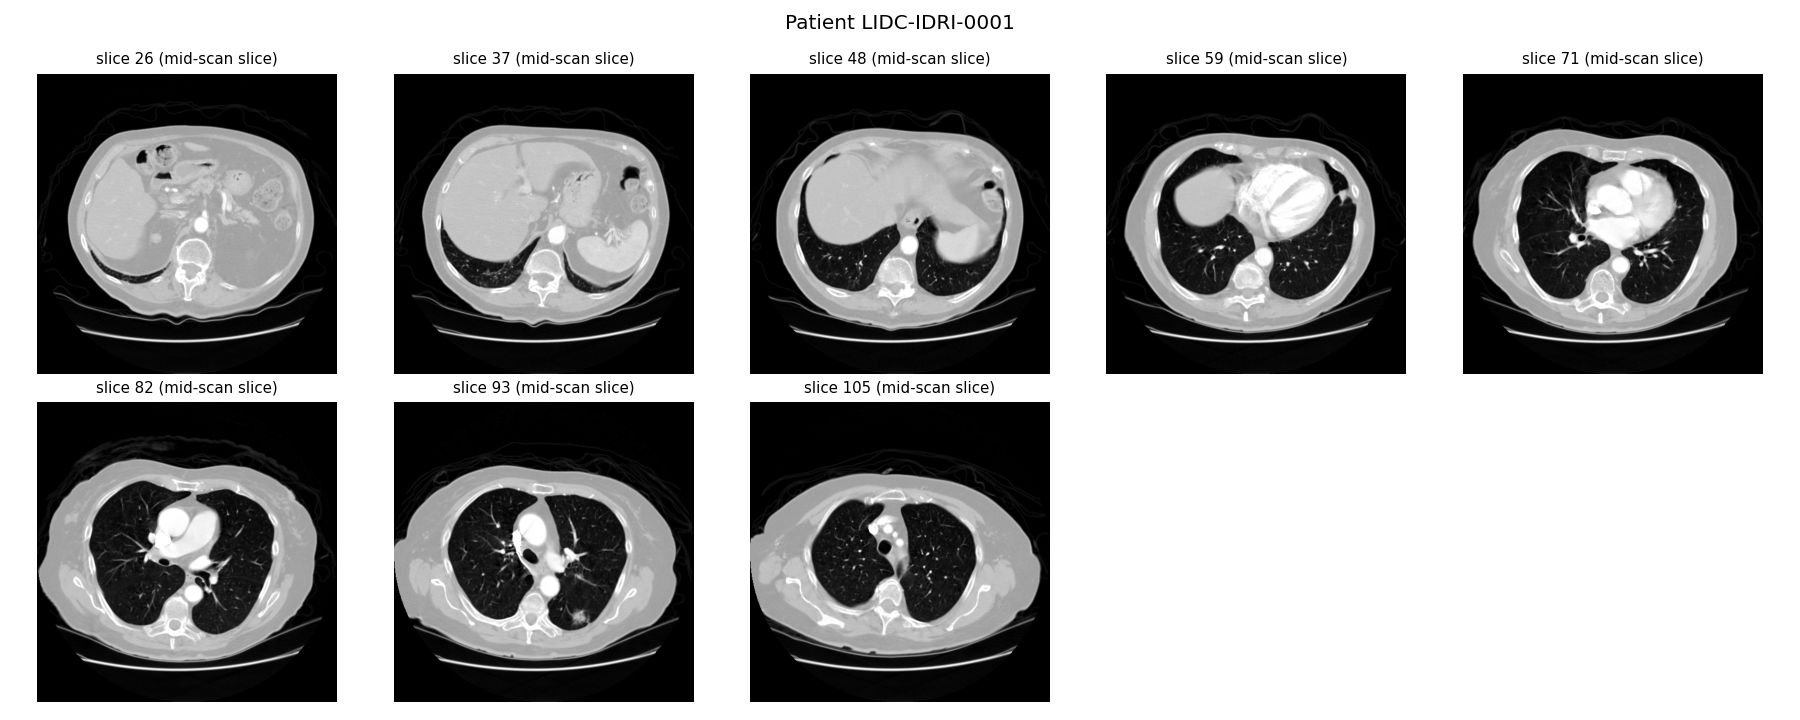

./lidc_exploration_output/LIDC-IDRI-0005_slices.png


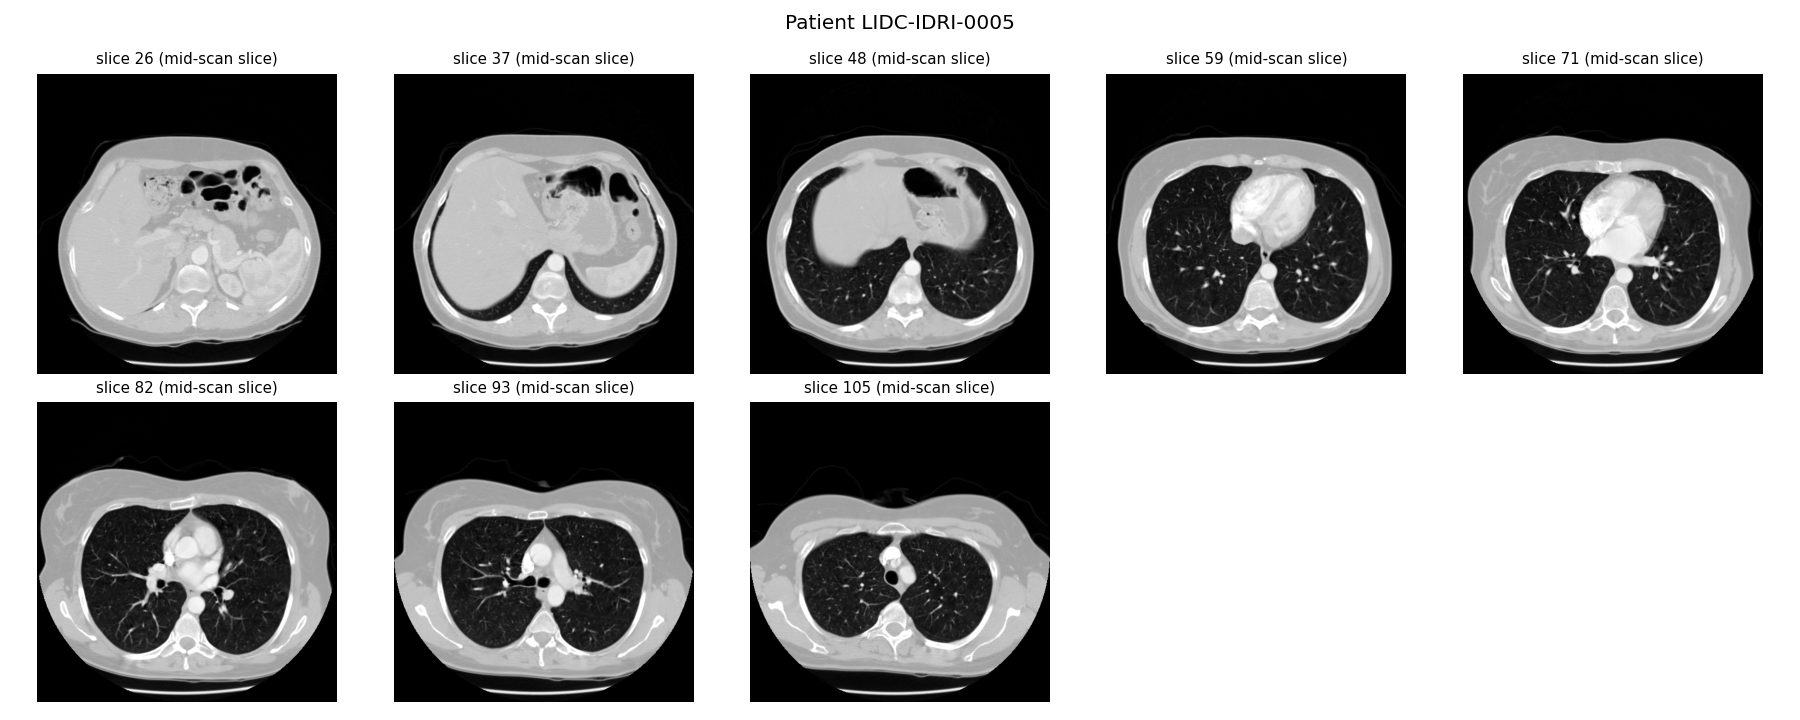

./lidc_exploration_output/LIDC-IDRI-0007_slices.png


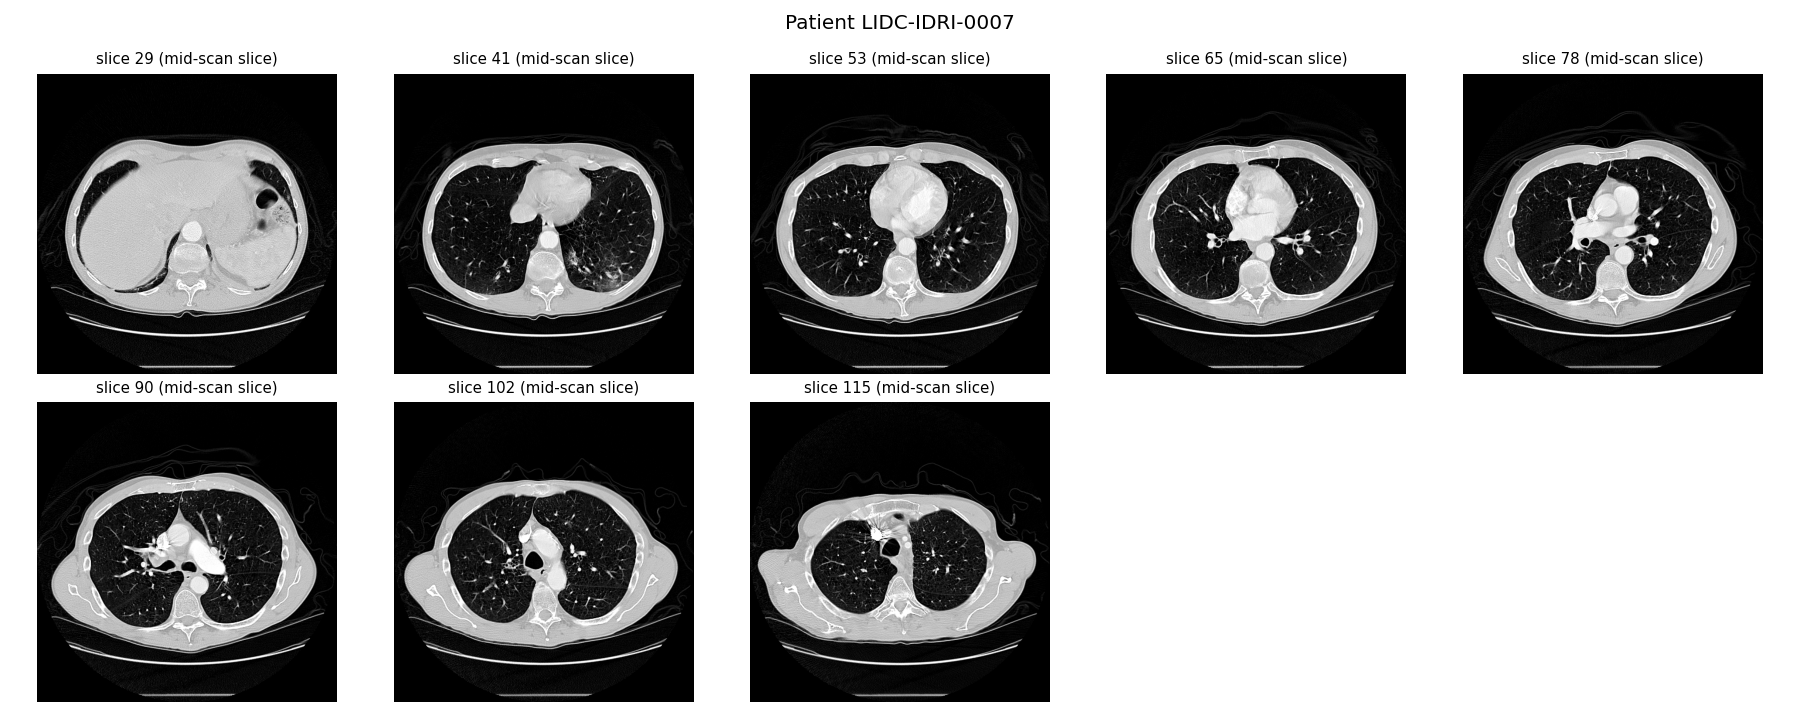

In [12]:
from IPython.display import Image, display
import glob

for f in sorted(glob.glob('./lidc_exploration_output/*.png')):
    print(f)
    display(Image(filename=f))

---

# TASK 04 - 06 &nbsp;|&nbsp; Baseline classifiers + MC-Dropout uncertainty

**Task 4** (due 28-Aug) Baseline ResNet-18 &nbsp;•&nbsp; **Task 5** (due 31-Aug) ViT baseline comparison &nbsp;•&nbsp; **Task 6** (due 04-Sep) MC-Dropout UQ

### Read this before running anything

Task 3 downloaded DICOM **pixel data** for 3 patients. It printed `no annotations found` for
every one of them, because `tcia_utils.nbia` retrieves image series only - the LIDC-IDRI nodule
annotations live in a **separate XML package**. Without those XMLs there is no malignancy rating,
therefore **no label**, therefore nothing for a classifier to learn.

So Section 1 below is the actual critical path, not the ResNet. It:

1. downloads DICOM for `N_PATIENTS` (not 3),
2. downloads + indexes the LIDC XML annotation package,
3. matches each nodule across the up-to-4 radiologists who read it,
4. takes the **median malignancy rating (1-5)** per nodule and applies the standard binary
   protocol (`<3` benign, `>3` malignant, `==3` dropped as ambiguous),
5. cuts a physically-sized patch around each nodule centroid and caches everything to one `.npz`.

**Run the build once, save it as a Kaggle Dataset, then never run it again.** Sections 2-6 read
only the cache, so model runs start in seconds instead of re-downloading tens of GB.

### How to run on Kaggle

| | |
|---|---|
| Accelerator | `GPU P100` or `GPU T4 x2` |
| Internet | **On** (required: TCIA download + pretrained weights) |
| Task 4 | `CFG["MODELS"] = ["resnet18"]` -> Run All -> Save Version |
| Task 5 | `CFG["MODELS"] = ["vit_small"]` -> Run All -> Save Version |
| Comparison | Section 5.3 loads both saved result files and runs DeLong + McNemar |
| Task 6 | Section 6 runs on whichever checkpoints exist |

`CFG["DATA_SOURCE"]` defaults to `"auto"`: it looks for a cached `.npz` in `/kaggle/input` first,
then in `/kaggle/working`, and only builds from raw LIDC if neither exists.

> If the cache is missing **and** you have no time to download, the notebook falls back to a
> synthetic phantom dataset so the code path is verifiable end-to-end. Every metric produced that
> way is stamped `SMOKE` and **must never be reported as a result.**

## 4.0 &nbsp;Configuration

Single source of truth for every hyperparameter in Tasks 4-6. Nothing below this cell hardcodes a
number that lives here.

In [ ]:
import os, sys, json, math, time, random, warnings, glob, zipfile, shutil
from pathlib import Path
warnings.filterwarnings("ignore")

CFG = dict(
    SEED = 42,

    # ---------- data source ----------
    DATA_SOURCE   = "auto",        # auto | cache | lidc_raw | phantom
    CACHE_NAME    = "lidc_nodules_cache.npz",
    WORK          = "/kaggle/working",
    RAW_DIR       = "/kaggle/temp/lidc_raw",     # /kaggle/temp is not size-capped like /working
    XML_DIR       = "/kaggle/temp/lidc_xml",

    # ---------- LIDC nodule extraction ----------
    N_PATIENTS    = 300,           # 300 patients ~ 700-900 usable nodules. Raise if quota allows.
    MIN_READERS   = 3,             # nodule must be marked by >= this many of the 4 radiologists
    DROP_SCORE_3  = True,          # median malignancy == 3 -> ambiguous -> excluded (standard)
    MATCH_MM      = 6.0,           # cross-reader nodule matching radius
    PATCH_MM      = 48.0,          # crop is 48mm x 48mm of real anatomy, resampled to IMG_SIZE
    IMG_SIZE      = 224,
    N_SLICES      = 3,             # 1 = single axial slice, 3 = 2.5D (3 adjacent slices -> RGB)
    HU_WINDOW     = (-1000.0, 400.0),

    # ---------- patient-level splits ----------
    TEST_FRAC     = 0.20,
    VAL_FRAC      = 0.15,          # fraction of the whole set, taken out of the train remainder

    # ---------- training ----------
    MODELS        = ["resnet18"],  # TASK 4: ["resnet18"]   TASK 5: ["vit_small"]
    PRETRAINED    = True,
    EPOCHS        = 30,
    BATCH_SIZE    = 32,
    LR            = 3e-4,
    WEIGHT_DECAY  = 1e-4,
    DROPOUT_P     = 0.30,          # TASK 6 needs this > 0 at train time
    DROPOUT_MODE  = "head_and_stages",   # head | head_and_stages
    PATIENCE      = 7,
    AMP           = True,
    NUM_WORKERS   = 2,
    CLASS_WEIGHTS = True,

    # ---------- evaluation ----------
    TARGET_SPECIFICITIES = [0.90, 0.95, 0.99],
    N_BOOTSTRAP   = 1000,
    N_ECE_BINS    = 15,

    # ---------- TASK 6 : MC dropout ----------
    MC_PASSES     = 50,
    UQ_TARGET_SENSITIVITY = 0.98,  # abstention threshold is calibrated on val to reach this
)

CFG["OUT_DIR"]    = f"{CFG['WORK']}/task456_outputs"
CFG["CACHE_PATH"] = f"{CFG['WORK']}/{CFG['CACHE_NAME']}"
Path(CFG["OUT_DIR"]).mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["benign", "malignant"]
IS_SMOKE = False          # flipped True by the phantom fallback; gates all reporting

print(json.dumps({k: v for k, v in CFG.items()}, indent=2, default=str))

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False   # keep benchmark speed; seeds still control init/sampling
    torch.backends.cudnn.benchmark = True

set_seed(CFG["SEED"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

# timm supplies the ViT for Task 5. Preinstalled on recent Kaggle images.
try:
    import timm
    print("timm", timm.__version__)
except ImportError:
    get_ipython().system("pip install -q timm")
    import timm
    print("timm", timm.__version__, "(freshly installed)")

## 4.1 &nbsp;Data layer - building labelled nodules from LIDC-IDRI

### 4.1.1 &nbsp;Why this section exists

The LIDC-IDRI label is not a column in a CSV. It is produced by up to four radiologists who each
independently outlined every nodule they saw and scored it on nine characteristics, malignancy
being one of them (1 = highly unlikely, 5 = highly suspicious). Turning that into a training label
requires three decisions, and every LIDC paper makes them - the numbers are only comparable
between papers that made them the same way. Ours, matching the dominant convention:

| Decision | Choice | Why |
|---|---|---|
| Which nodules to keep | marked by `MIN_READERS` = 3+ radiologists | 1-reader nodules are noisy and inflate scores |
| How to fuse the 4 ratings | **median** | robust to one dissenting reader; standard in the literature |
| What to do with median == 3 | **drop** | "indeterminate" is neither benign nor malignant; keeping it corrupts both classes |

These are recorded in `CFG` so the exact protocol is reproducible and quotable in the paper.
The other eight characteristics (spiculation, margin, subtlety, lobulation, calcification,
texture, sphericity, internal structure) are cached too - Task 8's concept-based explainability
(TCAV/ACE) needs them, and re-extracting later would mean re-downloading everything.

In [ ]:
import xml.etree.ElementTree as ET
from collections import defaultdict

def _tag(elem):
    """LIDC XMLs carry a namespace that varies between files. Compare on the local name only."""
    return elem.tag.split("}")[-1]

CHARACTERISTIC_KEYS = ["subtlety", "internalStructure", "calcification", "sphericity",
                       "margin", "lobulation", "spiculation", "texture", "malignancy"]

def parse_lidc_xml(xml_path):
    """One LIDC XML -> (series_uid, [reading_session, ...]).

    Each reading_session is one radiologist's list of nodules; each nodule carries its
    characteristic scores and its per-slice contours. Nodules with no <characteristics>
    block are the <3mm marks, which have no malignancy rating - dropped here.
    """
    root = ET.parse(xml_path).getroot()

    series_uid = None
    for e in root.iter():
        if _tag(e) in ("SeriesInstanceUid", "SeriesInstanceUID"):
            series_uid = (e.text or "").strip()
            break

    sessions = []
    for sess in root.iter():
        if _tag(sess) != "readingSession":
            continue
        nodules = []
        for nod in sess:
            if _tag(nod) != "unblindedReadNodule":
                continue
            nid, chars, rois = None, {}, []
            for child in nod:
                t = _tag(child)
                if t == "noduleID":
                    nid = (child.text or "").strip()
                elif t == "characteristics":
                    for c in child:
                        try:
                            chars[_tag(c)] = int(float((c.text or "").strip()))
                        except (TypeError, ValueError):
                            pass
                elif t == "roi":
                    z, sop, pts, included = None, None, [], True
                    for r in child:
                        rt = _tag(r)
                        if rt == "imageZposition":
                            z = float(r.text)
                        elif rt == "imageSOP_UID":
                            sop = (r.text or "").strip()
                        elif rt == "inclusion":
                            included = (r.text or "").strip().upper() == "TRUE"
                        elif rt == "edgeMap":
                            x = y = None
                            for e2 in r:
                                if _tag(e2) == "xCoord":   x = int(float(e2.text))
                                elif _tag(e2) == "yCoord": y = int(float(e2.text))
                            if x is not None and y is not None:
                                pts.append((x, y))
                    if pts and included:
                        rois.append(dict(z=z, sop=sop, pts=np.asarray(pts, dtype=np.float32)))
            # no malignancy score -> unusable as a label, however good the contour
            if rois and "malignancy" in chars:
                nodules.append(dict(nodule_id=nid, characteristics=chars, rois=rois))
        sessions.append(nodules)

    return series_uid, sessions


def nodule_geometry(nodule):
    """Centroid as (col, row, z_mm) plus the largest in-plane diameter, in pixels."""
    all_pts = np.concatenate([r["pts"] for r in nodule["rois"]], axis=0)
    cx, cy = all_pts[:, 0].mean(), all_pts[:, 1].mean()
    zs = [r["z"] for r in nodule["rois"] if r["z"] is not None]
    cz = float(np.mean(zs)) if zs else None
    diam_px = 0.0
    for r in nodule["rois"]:
        p = r["pts"]
        if len(p) > 1:
            diam_px = max(diam_px, float(np.hypot(np.ptp(p[:, 0]), np.ptp(p[:, 1]))))
    return float(cx), float(cy), cz, diam_px

### 4.1.2 &nbsp;Matching the same nodule across radiologists

The four readers worked blind to each other, so reader 1's "nodule 3" and reader 4's "nodule 1" may
be the same lesion. They must be grouped before the ratings can be fused. Grouping is by spatial
proximity of centroids in millimetres, with one constraint a naive nearest-neighbour pass would get
wrong: **a cluster may contain at most one nodule per reader.** Without it, two genuinely distinct
lesions that a single reader marked close together collapse into one cluster and its reader count
becomes meaningless - which then silently breaks the `MIN_READERS` filter.

In [ ]:
def cluster_nodules_across_readers(sessions, spacing_xy, match_mm):
    """Group per-reader nodule marks into physical lesions.

    Greedy agglomeration on centroid distance in mm, with the one-nodule-per-reader constraint.
    Returns a list of clusters; each cluster is a list of per-reader mark records.
    """
    items = []
    for r_idx, nodules in enumerate(sessions):
        for nod in nodules:
            cx, cy, cz, diam = nodule_geometry(nod)
            if cz is None:
                continue
            items.append(dict(reader=r_idx, nodule=nod, cx=cx, cy=cy, cz=cz, diam_px=diam))

    # Deterministic order so the same input always yields the same clusters.
    items.sort(key=lambda d: (d["cz"], d["cx"], d["cy"], d["reader"]))
    sx, sy = spacing_xy
    clusters = []

    for it in items:
        best, best_d = None, np.inf
        for cl in clusters:
            if any(m["reader"] == it["reader"] for m in cl):
                continue                                   # this reader is already represented
            mcx = np.mean([m["cx"] for m in cl]); mcy = np.mean([m["cy"] for m in cl])
            mcz = np.mean([m["cz"] for m in cl])
            d = math.sqrt(((it["cx"] - mcx) * sx) ** 2 +
                          ((it["cy"] - mcy) * sy) ** 2 +
                          (it["cz"] - mcz) ** 2)
            if d < best_d:
                best, best_d = cl, d
        if best is not None and best_d <= match_mm:
            best.append(it)
        else:
            clusters.append([it])
    return clusters


def fuse_cluster_labels(cluster, min_readers, drop_score_3):
    """Cluster of per-reader marks -> one labelled nodule, or None if it fails the protocol."""
    readers = sorted({m["reader"] for m in cluster})
    if len(readers) < min_readers:
        return None

    scores = defaultdict(list)
    for m in cluster:
        for k in CHARACTERISTIC_KEYS:
            if k in m["nodule"]["characteristics"]:
                scores[k].append(m["nodule"]["characteristics"][k])
    if not scores.get("malignancy"):
        return None

    mal_median = float(np.median(scores["malignancy"]))
    if drop_score_3 and abs(mal_median - 3.0) < 1e-9:
        return None
    label = int(mal_median > 3.0)

    return dict(
        n_readers   = len(readers),
        malignancy  = mal_median,
        label       = label,
        # Disagreement between readers. Task 6 uses this as a reference for irreducible
        # (aleatoric) label noise: cases the radiologists split on are cases the model
        # should be uncertain about too.
        mal_std     = float(np.std(scores["malignancy"])),
        mal_ratings = ",".join(str(int(v)) for v in scores["malignancy"]),
        cx = float(np.mean([m["cx"] for m in cluster])),
        cy = float(np.mean([m["cy"] for m in cluster])),
        cz = float(np.mean([m["cz"] for m in cluster])),
        diam_px = float(np.mean([m["diam_px"] for m in cluster])),
        **{f"c_{k}": float(np.median(v)) for k, v in scores.items()},
    )

### 4.1.3 &nbsp;Reading the CT series and cutting patches

Two details that matter more than they look:

**Patches are sized in millimetres, not pixels.** Pixel spacing across the 3 patients Task 3
already pulled ranges 0.664 - 0.781 mm. A fixed 64x64-pixel crop would therefore contain ~18% more
anatomy on one scan than another, and the network would be partly learning scanner settings. So we
crop `PATCH_MM` = 48 mm of real tissue and resample to `IMG_SIZE`, making nodule size physically
comparable across patients.

**`N_SLICES` = 3 gives a 2.5D input for free.** Three adjacent axial slices stacked as three
channels feed an ImageNet-pretrained 3-channel stem with no surgery, and carry some through-plane
context a single slice does not. Set it to 1 for a strict 2D baseline.

In [ ]:
def load_ct_series(series_dir):
    """Read one DICOM CT series -> HU volume sorted along z, plus geometry."""
    import pydicom
    paths = glob.glob(os.path.join(series_dir, "**", "*.dcm"), recursive=True)
    slices = []
    for p in paths:
        try:
            ds = pydicom.dcmread(p, force=True)
            if not hasattr(ds, "PixelData") or not hasattr(ds, "ImagePositionPatient"):
                continue
            if getattr(ds, "Modality", "CT") != "CT":
                continue
            slices.append(ds)
        except Exception:
            continue
    if len(slices) < 10:
        return None

    slices.sort(key=lambda d: float(d.ImagePositionPatient[2]))
    ref = slices[0]
    slope     = float(getattr(ref, "RescaleSlope", 1.0))
    intercept = float(getattr(ref, "RescaleIntercept", 0.0))
    spacing   = [float(v) for v in getattr(ref, "PixelSpacing", [1.0, 1.0])]

    vol = np.stack([s.pixel_array.astype(np.float32) for s in slices], axis=0)
    vol = vol * slope + intercept                   # stored values -> Hounsfield Units
    vol[vol < -2000] = -1000.0                      # outside-the-bore padding -> air

    return dict(
        vol       = vol,                                              # (z, y, x) HU
        z_pos     = np.array([float(s.ImagePositionPatient[2]) for s in slices]),
        spacing   = (spacing[1], spacing[0]),                         # (x, y) mm per pixel
        thickness = float(getattr(ref, "SliceThickness", 1.0)),
        n_slices  = len(slices),
        patient_id= str(getattr(ref, "PatientID", "")),
        series_uid= str(getattr(ref, "SeriesInstanceUID", "")),
    )


def window_to_uint8(patch_hu, hu_window):
    lo, hi = hu_window
    x = (np.clip(patch_hu, lo, hi) - lo) / (hi - lo)
    return (x * 255.0).astype(np.uint8)


def extract_patch(series, nod, patch_mm, img_size, n_slices, hu_window):
    """Nodule centroid -> (n_slices, img_size, img_size) uint8 patch, or None."""
    import cv2
    vol, z_pos = series["vol"], series["z_pos"]
    sx, sy = series["spacing"]

    z_idx  = int(np.argmin(np.abs(z_pos - nod["cz"])))
    half_x = max(2, int(round((patch_mm / 2.0) / sx)))
    half_y = max(2, int(round((patch_mm / 2.0) / sy)))
    cx, cy = int(round(nod["cx"])), int(round(nod["cy"]))

    offsets = [0] if n_slices == 1 else list(range(-(n_slices // 2), n_slices // 2 + 1))
    out = []
    for off in offsets:
        zi = int(np.clip(z_idx + off, 0, vol.shape[0] - 1))
        # Pad first, so a nodule against the chest wall still yields a full-size CENTRED crop.
        # Cropping first and padding after would shift the nodule off-centre.
        pad_y, pad_x = half_y + 1, half_x + 1
        padded = np.pad(vol[zi], ((pad_y, pad_y), (pad_x, pad_x)),
                        mode="constant", constant_values=hu_window[0])
        py, px = cy + pad_y, cx + pad_x
        crop = padded[py - half_y: py + half_y, px - half_x: px + half_x]
        if crop.size == 0:
            return None
        out.append(cv2.resize(window_to_uint8(crop, hu_window), (img_size, img_size),
                              interpolation=cv2.INTER_LINEAR))
    return np.stack(out, axis=0)

### 4.1.4 &nbsp;Fetching raw LIDC-IDRI (DICOM **and** the XML annotations Task 3 was missing)

`tcia_utils` handles the images. The annotations are a separate ~50 MB package. If the URL has moved
(TCIA reorganises its downloads periodically), the cell fails with printed instructions instead of
silently continuing with no labels - which is exactly the failure mode that produced the empty
`no annotations found` result in Task 3.

In [ ]:
def download_lidc_dicom(n_patients, out_dir):
    """Download one CT series per patient for the first n_patients (deterministic selection)."""
    try:
        from tcia_utils import nbia
    except ImportError:
        get_ipython().system("pip install -q tcia_utils")
        from tcia_utils import nbia

    os.makedirs(out_dir, exist_ok=True)
    df = pd.DataFrame(nbia.getSeries(collection="LIDC-IDRI"))
    df = df[df["Modality"] == "CT"].copy()               # LIDC also contains DX/CR radiographs
    df["ImageCount"] = pd.to_numeric(df["ImageCount"], errors="coerce").fillna(0)

    # One series per patient: the largest stack, i.e. the diagnostic CT rather than a scout.
    df = (df.sort_values(["PatientID", "ImageCount"], ascending=[True, False])
            .groupby("PatientID", as_index=False).first()
            .sort_values("PatientID"))
    sel = df.head(n_patients)
    print(f"LIDC-IDRI: {df.PatientID.nunique()} patients with CT | selecting {len(sel)}")
    print(f"Estimated download: ~{0.9 * sel.ImageCount.sum() / 1000:.1f} GB "
          f"({int(sel.ImageCount.sum())} slices)")

    nbia.downloadSeries(sel.to_dict("records"), path=out_dir)
    return sel


LIDC_XML_URLS = [
    "https://www.cancerimagingarchive.net/wp-content/uploads/LIDC-XML-only.zip",
    "https://wiki.cancerimagingarchive.net/download/attachments/1966254/LIDC-XML-only.zip",
]

def download_lidc_xml(xml_dir, urls=LIDC_XML_URLS):
    """Fetch + unzip the LIDC XML annotation package. Raises loudly if unavailable."""
    import requests
    os.makedirs(xml_dir, exist_ok=True)
    if glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True):
        print("XML annotations already present, skipping download.")
        return xml_dir

    zip_path = os.path.join(xml_dir, "LIDC-XML-only.zip")
    for url in urls:
        try:
            print("Trying", url)
            with requests.get(url, stream=True, timeout=180) as r:
                r.raise_for_status()
                with open(zip_path, "wb") as f:
                    for chunk in r.iter_content(1 << 20):
                        f.write(chunk)
            with zipfile.ZipFile(zip_path) as z:
                z.extractall(xml_dir)
            os.remove(zip_path)
            n = len(glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True))
            print(f"Extracted {n} annotation XMLs.")
            return xml_dir
        except Exception as e:
            print("  failed:", type(e).__name__, e)

    raise RuntimeError(
        "Could not fetch the LIDC XML annotation package automatically.\n"
        "MANUAL FIX (5 minutes, needed once):\n"
        "  1. Open the LIDC-IDRI collection page on cancerimagingarchive.net\n"
        "  2. Under Data Access / supporting documents, download 'LIDC-XML-only.zip'\n"
        "  3. Upload it as a Kaggle Dataset and attach it to this notebook\n"
        "  4. Set CFG['XML_DIR'] to that /kaggle/input/... path and re-run this cell\n"
        "Without these XMLs there are no malignancy labels and no supervised task."
    )


def index_xml_by_series(xml_dir):
    """SeriesInstanceUID -> xml path, so each downloaded series can find its annotations."""
    idx, files = {}, glob.glob(os.path.join(xml_dir, "**", "*.xml"), recursive=True)
    for p in files:
        try:
            uid, _ = parse_lidc_xml(p)
            if uid:
                idx[uid] = p
        except Exception:
            continue
    print(f"Indexed {len(idx)} / {len(files)} XMLs by SeriesInstanceUID.")
    return idx

In [ ]:
def build_lidc_cache(cfg):
    """Raw LIDC -> labelled-patch cache. Run ONCE, then save the .npz as a Kaggle Dataset."""
    import pydicom

    t0 = time.time()
    download_lidc_dicom(cfg["N_PATIENTS"], cfg["RAW_DIR"])
    xml_index = index_xml_by_series(download_lidc_xml(cfg["XML_DIR"]))

    patches, rows = [], []
    stats = defaultdict(int)
    series_dirs = [d for d in glob.glob(os.path.join(cfg["RAW_DIR"], "**"), recursive=True)
                   if os.path.isdir(d) and glob.glob(os.path.join(d, "*.dcm"))]
    print(f"Found {len(series_dirs)} series directories containing DICOM.")

    for i, sdir in enumerate(series_dirs, 1):
        series = load_ct_series(sdir)
        if series is None:
            stats["series_unreadable"] += 1
            continue

        suid = series["series_uid"] or os.path.basename(sdir)
        if suid not in xml_index:
            stats["series_no_annotation"] += 1
            continue

        _, sessions = parse_lidc_xml(xml_index[suid])
        clusters = cluster_nodules_across_readers(sessions, series["spacing"], cfg["MATCH_MM"])
        stats["clusters_found"] += len(clusters)

        kept = 0
        for cl in clusters:
            nod = fuse_cluster_labels(cl, cfg["MIN_READERS"], cfg["DROP_SCORE_3"])
            if nod is None:
                stats["rejected_by_protocol"] += 1
                continue
            patch = extract_patch(series, nod, cfg["PATCH_MM"], cfg["IMG_SIZE"],
                                  cfg["N_SLICES"], cfg["HU_WINDOW"])
            if patch is None:
                stats["patch_failed"] += 1
                continue
            nod["patient_id"] = series["patient_id"] or suid
            nod["series_uid"] = suid
            nod["diam_mm"]    = nod["diam_px"] * float(np.mean(series["spacing"]))
            patches.append(patch); rows.append(nod); kept += 1

        stats["series_used"] += 1
        if i % 25 == 0 or kept:
            print(f"  [{i}/{len(series_dirs)}] {series['patient_id']}: +{kept} nodules "
                  f"(total {len(patches)})")

        del series          # a 512x512x140 float32 volume is ~150 MB; do not accumulate them

    if not patches:
        raise RuntimeError(f"No nodules extracted. Diagnostics: {dict(stats)}")

    X    = np.stack(patches).astype(np.uint8)
    meta = pd.DataFrame(rows)
    np.savez_compressed(
        cfg["CACHE_PATH"],
        patches    = X,
        labels     = meta["label"].to_numpy(np.int64),
        malignancy = meta["malignancy"].to_numpy(np.float32),
        patient_id = meta["patient_id"].to_numpy(object),
        meta_json  = json.dumps(meta.to_dict("list"), default=str),
        cfg_json   = json.dumps({k: cfg[k] for k in
                                 ["MIN_READERS", "DROP_SCORE_3", "MATCH_MM", "PATCH_MM",
                                  "IMG_SIZE", "N_SLICES", "HU_WINDOW", "N_PATIENTS"]},
                                default=str),
    )
    print(f"\nBuild finished in {(time.time() - t0) / 60:.1f} min")
    print(f"  {X.shape[0]} nodules from {meta.patient_id.nunique()} patients")
    print(f"  cache -> {cfg['CACHE_PATH']}  ({os.path.getsize(cfg['CACHE_PATH'])/1e6:.0f} MB)")
    print(f"  diagnostics: {dict(stats)}")
    print("\n>>> Save this notebook version, then add its output .npz as a Kaggle Dataset")
    print(">>> so Tasks 4/5/6 never have to re-download.")
    return cfg["CACHE_PATH"]

### 4.1.5 &nbsp;Phantom fallback - `SMOKE` only

If no cache exists and the download cannot run, this generates synthetic lung-window patches so
Sections 2-6 can be executed and debugged. It sets a global `IS_SMOKE` flag and every results table
downstream is stamped with it.

**A `SMOKE` number proves the code runs. It is not a result.** Do not put one in the paper, the
Google Sheet, or an email to Dr. Sattar.

In [ ]:
def build_phantom_cache(cfg, n_patients=60, per_patient=12):
    """Synthetic stand-in: benign = round + smooth, malignant = irregular + spiculated."""
    import cv2
    rng = np.random.default_rng(cfg["SEED"])
    S, K = cfg["IMG_SIZE"], cfg["N_SLICES"]
    X, labels, pids, mal = [], [], [], []

    for p in range(n_patients):
        pid = f"PHANTOM-{p:04d}"
        for _ in range(per_patient):
            y = int(rng.random() < 0.40)
            base = cv2.GaussianBlur(rng.normal(0.25, 0.06, (S, S)).astype(np.float32), (0, 0), 6.0)
            yy, xx = np.mgrid[0:S, 0:S].astype(np.float32)
            cxp, cyp = S / 2 + rng.normal(0, 4, 2)
            r = S * rng.uniform(0.10, 0.20)
            theta = np.arctan2(yy - cyp, xx - cxp)
            k, amp = int(rng.integers(6, 12)), (0.32 if y else 0.06)   # spiculation proxy
            rr = r * (1.0 + amp * np.sin(k * theta + rng.uniform(0, 6.28)))
            blob = np.clip((rr - np.hypot(xx - cxp, yy - cyp)) / (0.18 * r), 0, 1)
            img = base + blob * rng.uniform(0.45, 0.70)
            if y:
                img += rng.normal(0, 0.05, (S, S)) * blob              # heterogeneous texture
            img = np.clip(cv2.GaussianBlur(img, (0, 0), 1.0), 0, 1)
            vol = np.stack([np.clip(img + rng.normal(0, 0.012, (S, S)), 0, 1) for _ in range(K)])
            X.append((vol * 255).astype(np.uint8))
            labels.append(y); pids.append(pid)
            mal.append(float(rng.integers(4, 6) if y else rng.integers(1, 3)))

    np.savez_compressed(cfg["CACHE_PATH"], patches=np.stack(X),
                        labels=np.asarray(labels, np.int64),
                        malignancy=np.asarray(mal, np.float32),
                        patient_id=np.asarray(pids, object),
                        meta_json=json.dumps({}), cfg_json=json.dumps({"PHANTOM": True}))
    print(f"PHANTOM cache: {len(X)} patches / {n_patients} pseudo-patients -> {cfg['CACHE_PATH']}")
    return cfg["CACHE_PATH"]

### 4.1.6 &nbsp;Source resolution

Preference order: an attached Kaggle Dataset cache, then a cache written earlier in this session,
then a fresh raw build, then the phantom. Override with `CFG["DATA_SOURCE"]`.

In [ ]:
def find_input_cache(cache_name):
    """Search attached Kaggle Datasets for a prebuilt cache with the right keys."""
    hits = glob.glob(f"/kaggle/input/**/{cache_name}", recursive=True)
    hits += [p for p in glob.glob("/kaggle/input/**/*.npz", recursive=True) if p not in hits]
    for p in hits:
        try:
            with np.load(p, allow_pickle=True) as z:
                if {"patches", "labels", "patient_id"} <= set(z.files):
                    return p
        except Exception:
            continue
    return None


def resolve_data(cfg):
    global IS_SMOKE
    src = cfg["DATA_SOURCE"]

    if src in ("auto", "cache"):
        p = find_input_cache(cfg["CACHE_NAME"])
        if p:
            print("Using cache from attached dataset:", p)
            return p
        if os.path.exists(cfg["CACHE_PATH"]):
            print("Using cache from this session:", cfg["CACHE_PATH"])
            return cfg["CACHE_PATH"]
        if src == "cache":
            raise FileNotFoundError("DATA_SOURCE='cache' but no cache was found.")

    if src in ("auto", "lidc_raw"):
        try:
            return build_lidc_cache(cfg)
        except Exception as e:
            print("\n" + "!" * 78)
            print("RAW LIDC BUILD FAILED:", type(e).__name__)
            print(e)
            print("!" * 78 + "\n")
            if src == "lidc_raw":
                raise

    print("\n" + "=" * 78)
    print("FALLING BACK TO SYNTHETIC PHANTOM DATA - RESULTS ARE NOT REPORTABLE")
    print("=" * 78 + "\n")
    IS_SMOKE = True
    return build_phantom_cache(cfg)


CACHE = resolve_data(CFG)

In [ ]:
with np.load(CACHE, allow_pickle=True) as z:
    PATCHES    = z["patches"]                          # (N, K, S, S) uint8
    LABELS     = z["labels"].astype(np.int64)
    MALIGNANCY = z["malignancy"].astype(np.float32)
    PATIENT_ID = np.asarray([str(v) for v in z["patient_id"]])
    BUILD_CFG  = json.loads(str(z["cfg_json"])) if "cfg_json" in z.files else {}
    _mj        = str(z["meta_json"]) if "meta_json" in z.files else "{}"
META = pd.DataFrame(json.loads(_mj)) if _mj not in ("{}", "", "None") else pd.DataFrame()

IS_SMOKE = IS_SMOKE or bool(BUILD_CFG.get("PHANTOM", False))

print(f"patches      : {PATCHES.shape}  {PATCHES.dtype}  ({PATCHES.nbytes/1e6:.0f} MB in RAM)")
print(f"patients     : {len(np.unique(PATIENT_ID))}")
print(f"nodules      : {len(LABELS)}")
print(f"class balance: benign={int((LABELS==0).sum())}  malignant={int((LABELS==1).sum())} "
      f"({100*LABELS.mean():.1f}% positive)")
print(f"build config : {BUILD_CFG}")
print(f"SMOKE MODE   : {IS_SMOKE}")
if len(META):
    print(f"characteristics cached for Task 8: "
          f"{[c for c in META.columns if c.startswith('c_')]}")

# A baseline trained on a handful of nodules gives a meaningless AUC with an enormous CI.
if not IS_SMOKE and len(LABELS) < 200:
    print(f"\nWARNING: only {len(LABELS)} nodules. Raise CFG['N_PATIENTS'] and rebuild before "
          f"reporting anything - patient-level confidence intervals will be uninterpretably wide.")

### 4.1.7 &nbsp;Patient-level splits

Splitting on nodules rather than patients is the most common way LIDC results get inflated: one
patient contributes several nodules from the same scanner, the same reconstruction kernel and the
same anatomy, so a nodule-level split leaks the test set into training and can add several AUC
points of pure illusion. Every split here is grouped by `patient_id`, and the assertion below
**fails the run** rather than letting a leak pass quietly.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

def patient_level_split(labels, groups, test_frac, val_frac, seed):
    """Grouped + stratified train/val/test: respects the patient constraint AND class ratio."""
    idx_all = np.arange(len(labels))

    k_test = max(2, int(round(1.0 / test_frac)))
    tr_pool, test_idx = next(StratifiedGroupKFold(
        n_splits=k_test, shuffle=True, random_state=seed).split(idx_all, labels, groups))

    val_share = val_frac / (1.0 - test_frac)
    k_val = max(2, int(round(1.0 / val_share)))
    sub_tr, sub_val = next(StratifiedGroupKFold(
        n_splits=k_val, shuffle=True, random_state=seed + 1
    ).split(tr_pool, labels[tr_pool], groups[tr_pool]))
    train_idx, val_idx = tr_pool[sub_tr], tr_pool[sub_val]

    for a, b, name in [(train_idx, val_idx, "train/val"), (train_idx, test_idx, "train/test"),
                       (val_idx, test_idx, "val/test")]:
        overlap = set(groups[a]) & set(groups[b])
        assert not overlap, f"PATIENT LEAK between {name}: {sorted(overlap)[:5]}"
    return train_idx, val_idx, test_idx


TRAIN_IDX, VAL_IDX, TEST_IDX = patient_level_split(
    LABELS, PATIENT_ID, CFG["TEST_FRAC"], CFG["VAL_FRAC"], CFG["SEED"])

SPLIT_TABLE = pd.DataFrame([
    dict(split=name, nodules=len(ix), patients=len(np.unique(PATIENT_ID[ix])),
         benign=int((LABELS[ix] == 0).sum()), malignant=int((LABELS[ix] == 1).sum()),
         pct_malignant=round(100 * float(LABELS[ix].mean()), 1))
    for name, ix in [("train", TRAIN_IDX), ("val", VAL_IDX), ("test", TEST_IDX)]
])
print(SPLIT_TABLE.to_string(index=False))
print("\nNo patient appears in more than one split (asserted).")
SPLIT_TABLE.to_csv(f"{CFG['OUT_DIR']}/splits.csv", index=False)

### 4.1.8 &nbsp;Dataset, augmentation, loaders

Augmentation is deliberately restrained. Flips and 90-degree rotations are safe on an axial lung
patch - a nodule has no canonical orientation. Aggressive intensity jitter is **not** safe: the
input is calibrated Hounsfield Units, and distorting them destroys the density information that
separates a solid nodule from a ground-glass one. Jitter is therefore kept small, and that choice
is a methodological claim worth stating in the paper rather than a default left unexamined.

In [ ]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class NoduleDataset(Dataset):
    """Returns (image, label, cache_index). The index is carried through so Task 6 can join
    per-sample uncertainty back to nodule metadata (diameter, reader disagreement, ...)."""

    def __init__(self, patches, labels, indices, train=False, seed=0):
        self.patches, self.labels, self.indices = patches, labels, indices
        self.train = train
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.indices)

    def _augment(self, x):
        if self.rng.random() < 0.5: x = np.flip(x, axis=2)
        if self.rng.random() < 0.5: x = np.flip(x, axis=1)
        x = np.ascontiguousarray(np.rot90(x, k=int(self.rng.integers(0, 4)), axes=(1, 2)))
        if self.rng.random() < 0.3:
            x = np.clip(x * self.rng.uniform(0.93, 1.07) +
                        self.rng.uniform(-0.04, 0.04), 0.0, 1.0)
        return x

    def __getitem__(self, i):
        j = self.indices[i]
        x = self.patches[j].astype(np.float32) / 255.0          # (K, S, S)
        if self.train:
            x = self._augment(x)
        x = torch.from_numpy(np.ascontiguousarray(x))
        if x.shape[0] == 1:
            x = x.repeat(3, 1, 1)                               # 2D baseline -> 3-channel stem
        elif x.shape[0] > 3:
            mid = x.shape[0] // 2
            x = x[mid - 1: mid + 2]
        elif x.shape[0] == 2:
            x = torch.cat([x, x[-1:]], dim=0)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        return x, torch.tensor(int(self.labels[j])), int(j)


def make_loaders(cfg):
    tr = NoduleDataset(PATCHES, LABELS, TRAIN_IDX, train=True,  seed=cfg["SEED"])
    va = NoduleDataset(PATCHES, LABELS, VAL_IDX,   train=False, seed=cfg["SEED"])
    te = NoduleDataset(PATCHES, LABELS, TEST_IDX,  train=False, seed=cfg["SEED"])

    if cfg["CLASS_WEIGHTS"]:
        cnt = np.bincount(LABELS[TRAIN_IDX], minlength=2).astype(np.float64)
        w = (1.0 / np.maximum(cnt, 1))[LABELS[TRAIN_IDX]]
        sampler, shuffle = WeightedRandomSampler(
            torch.as_tensor(w, dtype=torch.double), len(w), replacement=True), False
    else:
        sampler, shuffle = None, True

    common = dict(num_workers=cfg["NUM_WORKERS"], pin_memory=torch.cuda.is_available())
    return (DataLoader(tr, batch_size=cfg["BATCH_SIZE"], sampler=sampler, shuffle=shuffle,
                       drop_last=len(tr) > cfg["BATCH_SIZE"], **common),
            DataLoader(va, batch_size=cfg["BATCH_SIZE"] * 2, shuffle=False, **common),
            DataLoader(te, batch_size=cfg["BATCH_SIZE"] * 2, shuffle=False, **common))


TRAIN_LOADER, VAL_LOADER, TEST_LOADER = make_loaders(CFG)
print("batches -> train", len(TRAIN_LOADER), "| val", len(VAL_LOADER), "| test", len(TEST_LOADER))
xb, yb, jb = next(iter(TRAIN_LOADER))
print("batch tensor:", tuple(xb.shape), xb.dtype, "| labels:", yb.tolist()[:12])

In [ ]:
# Visual sanity check. LOOK AT THIS before trusting any metric: the nodule must sit in the middle
# of every patch. If it does not, the centroid/spacing handling in 4.1.3 is wrong and every number
# downstream is noise.
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(1.9 * n_show, 4.6))
for row, cls in enumerate([0, 1]):
    pool = TRAIN_IDX[LABELS[TRAIN_IDX] == cls][:n_show]
    for c in range(n_show):
        ax = axes[row, c]; ax.axis("off")
        if c >= len(pool):
            continue
        j = pool[c]
        ax.imshow(PATCHES[j][PATCHES[j].shape[0] // 2], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{CLASS_NAMES[cls]}\nmal={MALIGNANCY[j]:.1f}", fontsize=8)
fig.suptitle(f"Centre slice of training patches  |  {CFG['PATCH_MM']:.0f} mm field of view"
             + ("   [SMOKE / PHANTOM DATA]" if IS_SMOKE else ""), fontsize=11)
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/data_samples.png", dpi=110); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
vals, cnts = np.unique(MALIGNANCY, return_counts=True)
ax[0].bar([f"{v:.1f}" for v in vals], cnts, color="#6b8fd4")
ax[0].set_title("Median malignancy rating"
                + (" (score 3 excluded)" if CFG["DROP_SCORE_3"] else ""))
ax[0].set_xlabel("median rating across readers")
ax[1].bar(CLASS_NAMES, [int((LABELS == 0).sum()), int((LABELS == 1).sum())],
          color=["#5aa469", "#c95c5c"])
ax[1].set_title("Binary class balance")
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/label_distribution.png", dpi=110); plt.show()

## 4.2 &nbsp;Models

One factory, two architectures, one shared contract. Both return raw logits of shape `(B, 2)` and
both expose their dropout modules to `enable_mc_dropout()` in Task 6, so nothing downstream needs
to know which architecture it is holding.

### Why dropout is injected at *training* time, in Task 4

MC Dropout is not a post-hoc wrapper. It approximates a Bayesian posterior only if dropout was
**active during training**, so the network learned to be robust to its own units being masked. Adding
dropout to an already-trained deterministic network and sampling from it produces noise, not
calibrated uncertainty. So `DROPOUT_P` is set now, in the Task 4 baseline, even though the
uncertainty machinery is not used until Task 6 - the alternative is retraining everything next week.

`DROPOUT_MODE`:
- `head` - dropout only before the classifier. Cheap, but the uncertainty is shallow: only the last
  layer varies, so predictive variance is systematically under-dispersed.
- `head_and_stages` - additional 2D dropout after each residual stage. This is the configuration
  the UQ literature actually validates, and the default here.

In [ ]:
import torchvision

class MCDropout2d(nn.Dropout2d):
    """Marker subclass, so the layers WE inserted can be counted and reported separately from
    whatever dropout a third-party backbone brings with it. Task 6 samples over all of them;
    the distinction is for diagnostics, not for gating."""
    pass

class MCDropout(nn.Dropout):
    pass


class ResNet18Nodule(nn.Module):
    """TASK 4 baseline: ImageNet-pretrained ResNet-18 with MC-Dropout capability."""

    def __init__(self, n_classes=2, pretrained=True, p=0.3, mode="head_and_stages"):
        super().__init__()
        weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        net = torchvision.models.resnet18(weights=weights)
        self.n_features = net.fc.in_features                     # 512

        self.stem = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool)
        self.layer1, self.layer2 = net.layer1, net.layer2
        self.layer3, self.layer4 = net.layer3, net.layer4
        self.pool = nn.AdaptiveAvgPool2d(1)

        use_stage_drop = (mode == "head_and_stages")
        # Rising rate with depth: early features are generic and shared, late features are
        # task-specific and are where epistemic uncertainty actually lives.
        self.d1 = MCDropout2d(p * 0.25) if use_stage_drop else nn.Identity()
        self.d2 = MCDropout2d(p * 0.50) if use_stage_drop else nn.Identity()
        self.d3 = MCDropout2d(p * 0.75) if use_stage_drop else nn.Identity()
        self.d4 = MCDropout2d(p)        if use_stage_drop else nn.Identity()
        self.head_drop = MCDropout(p)
        self.fc = nn.Linear(self.n_features, n_classes)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.d1(self.layer1(x))
        x = self.d2(self.layer2(x))
        x = self.d3(self.layer3(x))
        x = self.d4(self.layer4(x))
        return x

    def forward(self, x):
        f = self.pool(self.forward_features(x)).flatten(1)
        return self.fc(self.head_drop(f))


class ViTNodule(nn.Module):
    """TASK 5 comparison: ImageNet-pretrained ViT / DeiT via timm.

    CAREFUL - drop_rate is not enough. In timm 1.x, drop_rate wires ONLY the classifier-head
    dropout; every dropout inside the transformer blocks stays at p=0.0. Passing drop_rate alone
    therefore builds a model with ~50 dropout modules that are all inert, and Task 6 would then
    sample over the final linear layer alone, producing a confident-looking uncertainty estimate
    with almost no variance in it. proj_drop_rate is the argument that actually reaches
    attn.proj_drop and mlp.drop1/drop2 in every block. Verified on timm 1.0.24: 37 active
    dropout layers with it, 1 without.

    attn_drop stays at 0 deliberately: dropping attention weights perturbs the attention
    distribution itself, which is not the perturbation MC Dropout theory assumes.
    """

    def __init__(self, n_classes=2, pretrained=True, p=0.3,
                 backbone="vit_small_patch16_224", img_size=224):
        super().__init__()
        self.backbone_name = backbone
        kwargs = dict(pretrained=pretrained, num_classes=0,   # num_classes=0 -> pooled features
                      drop_rate=p * 0.5, attn_drop_rate=0.0, img_size=img_size)
        try:
            self.body = timm.create_model(backbone, proj_drop_rate=p * 0.5, **kwargs)
        except TypeError:
            # older timm without proj_drop_rate - set the block dropout rates by hand
            self.body = timm.create_model(backbone, **kwargs)
            for mod_name, mod in self.body.named_modules():
                if isinstance(mod, nn.Dropout) and ("mlp.drop" in mod_name
                                                    or "proj_drop" in mod_name):
                    mod.p = p * 0.5

        self.n_features = self.body.num_features
        self.head_drop = MCDropout(p)
        self.fc = nn.Linear(self.n_features, n_classes)

    def forward_features(self, x):
        return self.body(x)

    def forward(self, x):
        return self.fc(self.head_drop(self.body(x)))


MODEL_REGISTRY = {
    "resnet18": lambda cfg: ResNet18Nodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                           cfg["DROPOUT_MODE"]),
    "vit_small": lambda cfg: ViTNodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                       "vit_small_patch16_224", cfg["IMG_SIZE"]),
    "deit_small": lambda cfg: ViTNodule(2, cfg["PRETRAINED"], cfg["DROPOUT_P"],
                                        "deit_small_patch16_224", cfg["IMG_SIZE"]),
}

def build_model(name, cfg):
    if name not in MODEL_REGISTRY:
        raise KeyError(f"Unknown model '{name}'. Available: {list(MODEL_REGISTRY)}")
    return MODEL_REGISTRY[name](cfg).to(DEVICE)


def count_active_dropout(model):
    """Dropout modules with p > 0. A module with p == 0 is inert - it injects no noise - so
    counting every Dropout instance would hide exactly the timm bug described above."""
    return sum(1 for m in model.modules()
               if isinstance(m, (nn.Dropout, nn.Dropout1d, nn.Dropout2d, nn.Dropout3d,
                                 nn.AlphaDropout)) and m.p > 0)


for name in MODEL_REGISTRY:
    try:
        m = MODEL_REGISTRY[name](dict(CFG, PRETRAINED=False))
        n_par   = sum(q.numel() for q in m.parameters()) / 1e6
        n_act   = count_active_dropout(m)
        n_inert = sum(1 for mod in m.modules() if isinstance(mod, nn.Dropout) and mod.p == 0)
        with torch.no_grad():
            out = m(torch.zeros(2, 3, CFG["IMG_SIZE"], CFG["IMG_SIZE"]))
        flag = "" if n_act >= 3 else "   <-- TOO FEW for meaningful MC Dropout, see Task 6"
        print(f"{name:12s} {n_par:6.1f}M params | {n_act:3d} ACTIVE dropout "
              f"({n_inert} inert) | out {tuple(out.shape)}{flag}")
        del m
    except Exception as e:
        print(f"{name:12s} FAILED: {type(e).__name__}: {e}")

## 4.3 &nbsp;Evaluation harness

Everything in this section is architecture-agnostic and gets reused by Tasks 4, 5 and 6 unchanged.
It implements the specific metrics the revised proposal (Section 6, "Statistical Evaluation" and
"False-Negative Evaluation") commits to:

| Metric | Why the proposal needs it |
|---|---|
| Accuracy / precision / recall / F1 / AUROC / AUPRC | baseline comparison table |
| **Sensitivity at fixed specificity** 0.90 / 0.95 / 0.99 | the false-negative requirement; a single accuracy number hides FNs |
| **Bootstrap 95% CIs**, resampled **by patient** | an interval, not a point estimate; resampling nodules would give falsely narrow CIs |
| **ECE + Brier** | calibration - required before any confidence threshold means anything |
| **DeLong test** | AUROC comparison ResNet vs ViT with a p-value |
| **McNemar test** | paired error comparison at the operating point |

The bootstrap resamples **patients, not nodules**. This matters: nodules from one patient are
correlated, so nodule-level resampling understates the variance and produces CIs that are too
narrow to be honest.

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, brier_score_loss)
from scipy import stats


def expected_calibration_error(y_true, p_pos, n_bins=15):
    """Equal-width binning ECE. Reported alongside Brier because Brier conflates calibration
    with discrimination, while ECE isolates the calibration part."""
    conf = np.where(p_pos >= 0.5, p_pos, 1.0 - p_pos)      # confidence in the predicted class
    correct = ((p_pos >= 0.5).astype(int) == y_true).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece, per_bin = 0.0, []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if not m.any():
            per_bin.append((0.5 * (lo + hi), np.nan, np.nan, 0)); continue
        acc, avg_conf = correct[m].mean(), conf[m].mean()
        ece += (m.sum() / len(conf)) * abs(acc - avg_conf)
        per_bin.append((0.5 * (lo + hi), acc, avg_conf, int(m.sum())))
    return float(ece), per_bin


def sensitivity_at_specificity(y_true, p_pos, target_spec):
    """Highest achievable sensitivity subject to specificity >= target, plus the threshold.
    This is the clinical operating point: in screening you fix the false-positive burden you
    can tolerate and then ask how many cancers you catch."""
    fpr, tpr, thr = roc_curve(y_true, p_pos)
    spec = 1.0 - fpr
    ok = spec >= target_spec
    if not ok.any():
        return np.nan, np.nan, np.nan
    i = int(np.argmax(np.where(ok, tpr, -np.inf)))
    return float(tpr[i]), float(spec[i]), float(thr[i])


def core_metrics(y_true, p_pos, threshold=0.5, cfg=CFG):
    y_pred = (p_pos >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    ece, _ = expected_calibration_error(y_true, p_pos, cfg["N_ECE_BINS"])

    out = dict(
        threshold   = float(threshold),
        n           = int(len(y_true)),
        accuracy    = float(accuracy_score(y_true, y_pred)),
        precision   = float(precision_score(y_true, y_pred, zero_division=0)),
        recall      = float(recall_score(y_true, y_pred, zero_division=0)),
        specificity = float(tn / (tn + fp)) if (tn + fp) else np.nan,
        f1          = float(f1_score(y_true, y_pred, zero_division=0)),
        auroc       = float(roc_auc_score(y_true, p_pos)) if len(np.unique(y_true)) > 1 else np.nan,
        auprc       = float(average_precision_score(y_true, p_pos)),
        brier       = float(brier_score_loss(y_true, p_pos)),
        ece         = float(ece),
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
        false_negative_rate = float(fn / (fn + tp)) if (fn + tp) else np.nan,
    )
    for ts in cfg["TARGET_SPECIFICITIES"]:
        sens, spec, thr = sensitivity_at_specificity(y_true, p_pos, ts)
        out[f"sens_at_spec_{int(ts*100)}"] = sens
        out[f"thr_at_spec_{int(ts*100)}"]  = thr
    return out


def bootstrap_ci(y_true, p_pos, groups, metric_fn, n_boot=1000, seed=42, alpha=0.05):
    """Patient-level (cluster) bootstrap: resample PATIENTS with replacement, take all of a
    resampled patient's nodules. Nodule-level resampling would ignore within-patient
    correlation and report intervals that are too narrow."""
    rng = np.random.default_rng(seed)
    uniq = np.unique(groups)
    by_group = {g: np.where(groups == g)[0] for g in uniq}
    vals = []
    for _ in range(n_boot):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([by_group[g] for g in pick])
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            vals.append(metric_fn(y_true[idx], p_pos[idx]))
        except Exception:
            continue
    if not vals:
        return np.nan, np.nan, np.nan
    vals = np.asarray(vals, dtype=float)
    return (float(np.mean(vals)),
            float(np.percentile(vals, 100 * alpha / 2)),
            float(np.percentile(vals, 100 * (1 - alpha / 2))))

In [ ]:
# ---- DeLong test: is the AUROC difference between two models statistically significant? ----
# Fast implementation of Sun & Xu (2014), the standard for correlated ROC curves (same test set,
# two models -> the two AUCs are correlated, so an unpaired test would be wrong).

def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def _fast_delong(preds_sorted, n_pos):
    """preds_sorted: (k_models, n_samples) with all positives first."""
    m, k = n_pos, preds_sorted.shape[0]
    n = preds_sorted.shape[1] - m
    pos, neg = preds_sorted[:, :m], preds_sorted[:, m:]

    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m + n])
    for r in range(k):
        tx[r] = _compute_midrank(pos[r])
        ty[r] = _compute_midrank(neg[r])
        tz[r] = _compute_midrank(preds_sorted[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10))
    return aucs, sx / m + sy / n


def delong_roc_test(y_true, p_a, p_b):
    """Two-sided DeLong test. Returns (auc_a, auc_b, z, p_value)."""
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-y_true, kind="mergesort")      # positives first, ties stable
    n_pos = int(y_true.sum())
    preds = np.vstack([np.asarray(p_a, float), np.asarray(p_b, float)])[:, order]

    aucs, cov = _fast_delong(preds, n_pos)
    l = np.array([[1.0, -1.0]])
    var = float(l @ cov @ l.T)
    if var <= 0:
        return float(aucs[0]), float(aucs[1]), np.nan, np.nan
    z = float((aucs[0] - aucs[1]) / np.sqrt(var))
    # norm.sf, not 1 - norm.cdf: the latter underflows to exactly 0.0 for |z| > ~8 and would
    # print "p = 0", which is not a reportable p-value.
    return float(aucs[0]), float(aucs[1]), z, float(2.0 * stats.norm.sf(abs(z)))


def mcnemar_test(y_true, pred_a, pred_b):
    """Exact McNemar on the discordant pairs: do the two models make DIFFERENT mistakes on the
    same cases? Complements DeLong, which compares ranking rather than decisions."""
    a_ok = (np.asarray(pred_a) == y_true)
    b_ok = (np.asarray(pred_b) == y_true)
    n01 = int((~a_ok & b_ok).sum())      # A wrong, B right
    n10 = int((a_ok & ~b_ok).sum())      # A right, B wrong
    if n01 + n10 == 0:
        return n01, n10, 1.0
    p = float(stats.binomtest(min(n01, n10), n01 + n10, 0.5, alternative="two-sided").pvalue)
    return n01, n10, p


# Self-check on synthetic data: a clearly better scorer must come out with a small p-value.
_rng = np.random.default_rng(0)
_y = np.r_[np.ones(120), np.zeros(120)].astype(int)
_good = np.r_[_rng.normal(1.6, 1, 120), _rng.normal(0, 1, 120)]
_weak = np.r_[_rng.normal(0.4, 1, 120), _rng.normal(0, 1, 120)]
_a, _b, _z, _p = delong_roc_test(_y, _good, _weak)
print(f"DeLong self-check: auc_good={_a:.3f} auc_weak={_b:.3f} z={_z:.2f} p={_p:.2e}")
assert _p < 0.01 and _a > _b, "DeLong implementation is broken"
# A large |z| must still give a representable p. 1 - norm.cdf(|z|) hits exactly 0.0 around
# |z| = 8.3, so a strong result would print "p = 0" - not a reportable number.
_p_extreme = float(2.0 * stats.norm.sf(12.0))
assert _p_extreme > 0.0, "p-value underflowed - delong_roc_test must use norm.sf, not 1-norm.cdf"
print(f"  p at z=12 stays representable: {_p_extreme:.3e}  "
      f"(1-norm.cdf would give {2.0*(1.0-stats.norm.cdf(12.0)):.1f})")
print("McNemar self-check:", mcnemar_test(_y, (_good > 0.8).astype(int), (_weak > 0.2).astype(int)))

## 4.4 &nbsp;Training loop

Shared by Tasks 4 and 5, so the ViT/CNN comparison differs **only** in the architecture - same
data, same schedule, same optimiser, same early-stopping rule, same seed. Any other design lets a
reviewer object that the comparison measures tuning effort rather than architecture.

Model selection is on **validation AUROC**, not validation accuracy. With class imbalance and a
threshold that will be re-tuned for the clinical operating point anyway, accuracy at 0.5 is the
wrong quantity to select on.

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

@torch.no_grad()
def predict_deterministic(model, loader):
    """Standard single-pass inference. Dropout OFF - this is the Task 4/5 baseline prediction."""
    model.eval()
    P, Y, J = [], [], []
    for x, y, j in loader:
        logits = model(x.to(DEVICE, non_blocking=True))
        P.append(torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
        Y.append(y.numpy()); J.append(np.asarray(j))
    return np.concatenate(P), np.concatenate(Y), np.concatenate(J)


def train_model(name, cfg, train_loader, val_loader, verbose=True):
    set_seed(cfg["SEED"])
    model = build_model(name, cfg)

    if cfg["CLASS_WEIGHTS"]:
        cnt = np.bincount(LABELS[TRAIN_IDX], minlength=2).astype(np.float32)
        # WeightedRandomSampler already balances the stream; a mild residual weight guards the
        # case where the sampler is disabled.
        w = torch.tensor(cnt.sum() / (2.0 * np.maximum(cnt, 1)), dtype=torch.float32, device=DEVICE)
        criterion = nn.CrossEntropyLoss(weight=w)
    else:
        criterion = nn.CrossEntropyLoss()

    opt = AdamW(model.parameters(), lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])
    sched = CosineAnnealingLR(opt, T_max=cfg["EPOCHS"])
    use_amp = cfg["AMP"] and DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    ckpt = f"{cfg['OUT_DIR']}/{name}_best.pt"
    best_auc, best_epoch, bad, history = -np.inf, -1, 0, []
    t0 = time.time()

    for epoch in range(1, cfg["EPOCHS"] + 1):
        model.train()
        tot, seen = 0.0, 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            tot += loss.item() * x.size(0); seen += x.size(0)
        sched.step()

        p_val, y_val, _ = predict_deterministic(model, val_loader)
        val_auc = roc_auc_score(y_val, p_val) if len(np.unique(y_val)) > 1 else np.nan
        val_acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))
        history.append(dict(epoch=epoch, train_loss=tot / max(seen, 1),
                            val_auroc=float(val_auc), val_acc=float(val_acc),
                            lr=opt.param_groups[0]["lr"]))

        improved = np.isfinite(val_auc) and val_auc > best_auc + 1e-5
        if improved:
            best_auc, best_epoch, bad = float(val_auc), epoch, 0
            torch.save(dict(model=model.state_dict(), cfg=cfg, name=name,
                            epoch=epoch, val_auroc=best_auc), ckpt)
        else:
            bad += 1

        if verbose:
            print(f"  epoch {epoch:3d}/{cfg['EPOCHS']} | loss {history[-1]['train_loss']:.4f} "
                  f"| val AUROC {val_auc:.4f} | val acc {val_acc:.4f}"
                  f"{'  <- best' if improved else ''}")
        if bad >= cfg["PATIENCE"]:
            print(f"  early stop at epoch {epoch} (no val AUROC gain for {bad} epochs)")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE)["model"])
    print(f"  restored best epoch {best_epoch} (val AUROC {best_auc:.4f}) "
          f"| {(time.time()-t0)/60:.1f} min")
    return model, pd.DataFrame(history), ckpt


def plot_history(hist, title):
    fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
    ax[0].plot(hist.epoch, hist.train_loss, color="#c95c5c")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].set_title("Training loss")
    ax[1].plot(hist.epoch, hist.val_auroc, label="val AUROC", color="#3b6ea5")
    ax[1].plot(hist.epoch, hist.val_acc, label="val accuracy", color="#5aa469", ls="--")
    ax[1].axvline(hist.val_auroc.idxmax() + 1, color="grey", ls=":", lw=1)
    ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].set_title("Validation")
    fig.suptitle(title + ("   [SMOKE]" if IS_SMOKE else ""))
    plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/{title.replace(' ','_')}_history.png", dpi=110)
    plt.show()

In [ ]:
def evaluate_and_report(name, p_test, y_test, j_test, cfg=CFG, tag="deterministic"):
    """Full metric block + bootstrap CIs + saved artefacts. Used by Tasks 4, 5 and 6."""
    groups = PATIENT_ID[j_test]
    m = core_metrics(y_test, p_test, 0.5, cfg)
    m.update(model=name, tag=tag, smoke=IS_SMOKE,
             n_test_patients=int(len(np.unique(groups))))

    for key, fn in [("auroc", lambda a, b: roc_auc_score(a, b)),
                    ("auprc", lambda a, b: average_precision_score(a, b)),
                    ("accuracy", lambda a, b: accuracy_score(a, (b >= 0.5).astype(int))),
                    ("recall", lambda a, b: recall_score(a, (b >= 0.5).astype(int),
                                                         zero_division=0)),
                    ("f1", lambda a, b: f1_score(a, (b >= 0.5).astype(int), zero_division=0))]:
        mean, lo, hi = bootstrap_ci(y_test, p_test, groups, fn,
                                    cfg["N_BOOTSTRAP"], cfg["SEED"])
        m[f"{key}_ci_low"], m[f"{key}_ci_high"] = lo, hi

    banner = f"  {name} / {tag}  " + ("[SMOKE - NOT REPORTABLE]" if IS_SMOKE else "")
    print("=" * 78); print(banner); print("=" * 78)
    print(f"  test set: {m['n']} nodules from {m['n_test_patients']} patients")
    print(f"  AUROC        {m['auroc']:.4f}  [{m['auroc_ci_low']:.4f}, {m['auroc_ci_high']:.4f}]")
    print(f"  AUPRC        {m['auprc']:.4f}  [{m['auprc_ci_low']:.4f}, {m['auprc_ci_high']:.4f}]")
    print(f"  Accuracy     {m['accuracy']:.4f}  [{m['accuracy_ci_low']:.4f}, "
          f"{m['accuracy_ci_high']:.4f}]")
    print(f"  Sensitivity  {m['recall']:.4f}  [{m['recall_ci_low']:.4f}, {m['recall_ci_high']:.4f}]")
    print(f"  Specificity  {m['specificity']:.4f}")
    print(f"  Precision    {m['precision']:.4f}      F1  {m['f1']:.4f}")
    print(f"  Brier        {m['brier']:.4f}      ECE {m['ece']:.4f}")
    print(f"  Confusion    TP={m['tp']} FP={m['fp']} TN={m['tn']} FN={m['fn']}"
          f"   (FN rate {m['false_negative_rate']:.3f})")
    print("  -- clinical operating points (the false-negative requirement) --")
    for ts in cfg["TARGET_SPECIFICITIES"]:
        s = m[f"sens_at_spec_{int(ts*100)}"]
        t = m[f"thr_at_spec_{int(ts*100)}"]
        print(f"    sensitivity @ specificity>={ts:.2f} : "
              + (f"{s:.4f}  (threshold {t:.4f})" if np.isfinite(s) else "not achievable"))

    np.savez(f"{cfg['OUT_DIR']}/{name}_{tag}_predictions.npz",
             p=p_test, y=y_test, cache_index=j_test, patient_id=groups)
    with open(f"{cfg['OUT_DIR']}/{name}_{tag}_metrics.json", "w") as f:
        json.dump(m, f, indent=2, default=float)
    return m


def plot_roc_pr(curves, title):
    """curves: list of (label, y_true, p_pos)."""
    from sklearn.metrics import precision_recall_curve
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    for label, y, p in curves:
        fpr, tpr, _ = roc_curve(y, p)
        ax[0].plot(fpr, tpr, lw=1.8, label=f"{label} (AUC {roc_auc_score(y, p):.3f})")
        pr, rc, _ = precision_recall_curve(y, p)
        ax[1].plot(rc, pr, lw=1.8, label=f"{label} (AP {average_precision_score(y, p):.3f})")
    ax[0].plot([0, 1], [0, 1], "k:", lw=1)
    for ts in CFG["TARGET_SPECIFICITIES"]:
        ax[0].axvline(1 - ts, color="grey", ls="--", lw=0.7)
        ax[0].text(1 - ts, 0.02, f"spec {ts:.2f}", rotation=90, fontsize=7, color="grey")
    ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity")
    ax[0].set_title("ROC"); ax[0].legend(loc="lower right", fontsize=8)
    ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
    ax[1].set_title("Precision-Recall"); ax[1].legend(loc="lower left", fontsize=8)
    fig.suptitle(title + ("   [SMOKE]" if IS_SMOKE else ""))
    plt.tight_layout()
    plt.savefig(f"{CFG['OUT_DIR']}/{title.replace(' ','_').replace('/','-')}_roc_pr.png", dpi=110)
    plt.show()


RESULTS = []   # accumulates every metric dict produced in this notebook

---

# TASK 04 &nbsp;|&nbsp; 4.5 Baseline ResNet-18 - training run
**Due 28-Aug.** This is the reference number every later contribution is measured against, so it
has to be an *honest* baseline: same data, same splits, same protocol as everything that follows,
with no tuning advantage and no leakage.

Set `CFG["MODELS"] = ["resnet18"]` and run. Trained checkpoints and predictions land in
`CFG["OUT_DIR"]` and are reused by Task 5's comparison and Task 6's UQ.

In [ ]:
TRAINED = {}          # name -> dict(model, ckpt, history, preds)

def run_model(name, cfg=CFG):
    print("\n" + "#" * 78)
    print(f"#  TRAINING {name}" + ("   [SMOKE DATA]" if IS_SMOKE else ""))
    print("#" * 78)
    model, hist, ckpt = train_model(name, cfg, TRAIN_LOADER, VAL_LOADER)
    plot_history(hist, f"{name} training")

    p_te, y_te, j_te = predict_deterministic(model, TEST_LOADER)
    p_va, y_va, j_va = predict_deterministic(model, VAL_LOADER)
    m = evaluate_and_report(name, p_te, y_te, j_te, cfg, tag="deterministic")
    RESULTS.append(m)

    TRAINED[name] = dict(model=model, ckpt=ckpt, history=hist,
                         test=(p_te, y_te, j_te), val=(p_va, y_va, j_va), metrics=m)
    hist.to_csv(f"{cfg['OUT_DIR']}/{name}_history.csv", index=False)
    return TRAINED[name]


for _name in CFG["MODELS"]:
    run_model(_name, CFG)

In [ ]:
# ROC / PR for whatever was trained in this run.
if TRAINED:
    plot_roc_pr([(n, d["test"][1], d["test"][0]) for n, d in TRAINED.items()],
                "Test ROC and PR")

    fig, axes = plt.subplots(1, len(TRAINED), figsize=(4.2 * len(TRAINED), 3.6), squeeze=False)
    for ax, (n, d) in zip(axes[0], TRAINED.items()):
        p, y, _ = d["test"]
        cm = confusion_matrix(y, (p >= 0.5).astype(int), labels=[0, 1])
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for k in range(2):
                ax.text(k, i, cm[i, k], ha="center", va="center",
                        color="white" if cm[i, k] > cm.max() / 2 else "black", fontsize=13)
        ax.set_xticks([0, 1], CLASS_NAMES); ax.set_yticks([0, 1], CLASS_NAMES)
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.set_title(f"{n}\nFN = {cm[1,0]}  (missed cancers)")
    plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/confusion_matrices.png", dpi=110); plt.show()

---

# TASK 05 &nbsp;|&nbsp; ViT baseline comparison
**Due 31-Aug.**

### How to run this

Do **not** train both models in one Kaggle session unless the dataset is small - a P100 session is
capped at ~9 h and ViT-Small is roughly 4x the compute of ResNet-18 per epoch. Instead:

1. `CFG["MODELS"] = ["resnet18"]` -> Run All -> **Save Version**
2. `CFG["MODELS"] = ["vit_small"]` -> Run All -> **Save Version**
3. Attach both output versions to the notebook (or just run 5.2 in the second session, where the
   first version's outputs are already in `/kaggle/input`)
4. Section 5.2 loads whatever prediction files it can find and runs the paired tests

### Fairness constraints (state these in the paper)

Identical splits, identical augmentation, identical optimiser/schedule/seed, identical
early-stopping rule, both ImageNet-pretrained. The *only* difference is the architecture. Note the
one asymmetry that cannot be removed: ViT-Small has ~21 M parameters against ResNet-18's ~11 M, and
transformers are known to be more data-hungry - so on a few-hundred-nodule LIDC subset a ResNet win
is the expected result and is not evidence that ViTs are worse in general. Say so explicitly rather
than letting a reviewer say it for you.

In [ ]:
# ---- 5.1 Optional: train the second architecture in this same session ----
# Uncomment only if the dataset is small enough that both fit in the GPU quota.

# run_model("vit_small", CFG)
print("Trained in this session:", list(TRAINED) or "none")

In [ ]:
# ---- 5.2 Load predictions from earlier saved versions so the comparison spans sessions ----

def load_saved_predictions(tag="deterministic"):
    """Collect <model>_<tag>_predictions.npz from this session's output and any attached dataset."""
    found = {}
    for root in [CFG["OUT_DIR"], "/kaggle/input"]:
        for p in glob.glob(f"{root}/**/*_{tag}_predictions.npz", recursive=True):
            name = os.path.basename(p).replace(f"_{tag}_predictions.npz", "")
            if name in found:
                continue                                  # this session's output wins
            with np.load(p, allow_pickle=True) as z:
                found[name] = dict(p=z["p"], y=z["y"], j=z["cache_index"],
                                   patient_id=np.asarray([str(v) for v in z["patient_id"]]),
                                   source=p)
    return found


PREDS = {n: dict(p=d["test"][0], y=d["test"][1], j=d["test"][2],
                 patient_id=PATIENT_ID[d["test"][2]], source="this session")
         for n, d in TRAINED.items()}
for n, d in load_saved_predictions().items():
    PREDS.setdefault(n, d)

for n, d in PREDS.items():
    print(f"{n:12s} n={len(d['y']):5d}  AUROC={roc_auc_score(d['y'], d['p']):.4f}  <- {d['source']}")

In [ ]:
# ---- 5.3 Head-to-head: DeLong on AUROC, McNemar on decisions ----

def compare_models(preds, cfg=CFG):
    names = sorted(preds)
    if len(names) < 2:
        print("Need predictions from >= 2 models. Run the other architecture and save a version,\n"
              "or uncomment 5.1 to train both here.")
        return None

    rows = []
    for i in range(len(names)):
        for k in range(i + 1, len(names)):
            a, b = names[i], names[k]
            da, db = preds[a], preds[b]

            # The two runs must be scored on the SAME test nodules or the paired tests are invalid.
            common = np.intersect1d(da["j"], db["j"])
            if len(common) < 10:
                print(f"{a} vs {b}: only {len(common)} shared test nodules - "
                      f"were they built from the same cache? Skipping.")
                continue
            pa_pos = {int(c): i for i, c in enumerate(da["j"])}
            pb_pos = {int(c): i for i, c in enumerate(db["j"])}
            ia = np.array([pa_pos[int(c)] for c in common], dtype=int)
            ib = np.array([pb_pos[int(c)] for c in common], dtype=int)
            y = da["y"][ia]
            assert np.array_equal(y, db["y"][ib]), "label mismatch on shared nodules"
            pa, pb = da["p"][ia], db["p"][ib]

            auc_a, auc_b, z, p_delong = delong_roc_test(y, pa, pb)
            n01, n10, p_mcnemar = mcnemar_test(y, (pa >= 0.5).astype(int), (pb >= 0.5).astype(int))
            fn_a = int(((pa < 0.5) & (y == 1)).sum())
            fn_b = int(((pb < 0.5) & (y == 1)).sum())

            rows.append(dict(model_a=a, model_b=b, n_shared=len(common),
                             auroc_a=auc_a, auroc_b=auc_b, auroc_diff=auc_a - auc_b,
                             delong_z=z, delong_p=p_delong,
                             mcnemar_b_only_correct=n01, mcnemar_a_only_correct=n10,
                             mcnemar_p=p_mcnemar,
                             false_negatives_a=fn_a, false_negatives_b=fn_b,
                             smoke=IS_SMOKE))

            print("=" * 78)
            print(f"  {a}  vs  {b}   ({len(common)} shared test nodules)")
            print("=" * 78)
            print(f"  AUROC  {a}: {auc_a:.4f}    {b}: {auc_b:.4f}    diff: {auc_a-auc_b:+.4f}")
            print(f"  DeLong   z = {z:+.3f},  p = {p_delong:.4g}"
                  f"   -> {'significant' if p_delong < 0.05 else 'NOT significant'} at alpha=0.05")
            print(f"  McNemar  discordant {n10} / {n01},  p = {p_mcnemar:.4g}"
                  f"   -> {'significant' if p_mcnemar < 0.05 else 'NOT significant'}")
            print(f"  False negatives at 0.5:  {a} = {fn_a},  {b} = {fn_b}")
            if p_delong >= 0.05:
                print(f"\n  Interpretation: with {len(common)} test nodules this study is not "
                      f"powered\n  to separate these architectures. Report the CIs and say so - "
                      f"do not\n  claim a winner from a non-significant difference.")

    df = pd.DataFrame(rows)
    if len(df):
        df.to_csv(f"{cfg['OUT_DIR']}/model_comparison.csv", index=False)
    return df


COMPARISON = compare_models(PREDS)

In [ ]:
# ---- 5.4 Combined comparison table for the paper / the Google Sheet ----

def comparison_table(preds, cfg=CFG):
    rows = []
    for n, d in sorted(preds.items()):
        m = core_metrics(d["y"], d["p"], 0.5, cfg)
        _, lo, hi = bootstrap_ci(d["y"], d["p"], d["patient_id"],
                                 lambda a, b: roc_auc_score(a, b),
                                 cfg["N_BOOTSTRAP"], cfg["SEED"])
        rows.append({
            "model": n,
            "AUROC": f"{m['auroc']:.3f} [{lo:.3f}-{hi:.3f}]",
            "AUPRC": f"{m['auprc']:.3f}",
            "Accuracy": f"{m['accuracy']:.3f}",
            "Sensitivity": f"{m['recall']:.3f}",
            "Specificity": f"{m['specificity']:.3f}",
            "F1": f"{m['f1']:.3f}",
            "ECE": f"{m['ece']:.3f}",
            "Brier": f"{m['brier']:.3f}",
            "FN": m["fn"],
            "Sens@Spec90": f"{m['sens_at_spec_90']:.3f}" if np.isfinite(
                m["sens_at_spec_90"]) else "n/a",
            "Sens@Spec95": f"{m['sens_at_spec_95']:.3f}" if np.isfinite(
                m["sens_at_spec_95"]) else "n/a",
        })
    df = pd.DataFrame(rows)
    df.to_csv(f"{cfg['OUT_DIR']}/comparison_table.csv", index=False)
    return df


TABLE = comparison_table(PREDS)
print(("[SMOKE DATA - NOT REPORTABLE]\n" if IS_SMOKE else "") + TABLE.to_string(index=False))

if len(PREDS) >= 2:
    plot_roc_pr([(n, d["y"], d["p"]) for n, d in sorted(PREDS.items())],
                "ResNet-18 vs ViT on the test set")

---

# TASK 06 &nbsp;|&nbsp; MC-Dropout uncertainty quantification
**Due 04-Sep.** This section produces the uncertainty signal Dr. Sattar's orchestrator consumes for
dynamic model selection, so Section 6.5 defines the **interface contract** explicitly rather than
leaving it to be discovered by reading code.

### What MC Dropout actually gives you

Keep dropout active at inference and run `T` forward passes. Each pass is a sample from an
approximate posterior over weights, so you get `T` different probability estimates per nodule
instead of one. Three numbers come out of that spread, and they are **not interchangeable**:

| Quantity | Formula | Reads as |
|---|---|---|
| **Predictive entropy** | `H(mean_t p_t)` | total uncertainty |
| **Expected entropy** | `mean_t H(p_t)` | **aleatoric** - noise in the data itself; more data will not fix it |
| **Mutual information** | `H(mean) - mean H` | **epistemic** - the model does not know; more data *would* fix it |

The split is what makes this useful for routing. High **epistemic** uncertainty is the orchestrator's
cue to escalate - a different model, test-time augmentation, an ensemble - because the case is
outside what this model learned. High **aleatoric** uncertainty on a genuinely ambiguous lesion means
escalation is wasted compute and the case should go to a human. A single "confidence" scalar cannot
tell those two apart, which is exactly why the contract below exposes both.

### One critical implementation detail

`model.train()` would also put **BatchNorm** into training mode, which recomputes batch statistics
from the inference batch. Predictions would then depend on which other nodules happen to share the
batch - non-deterministic in a way that has nothing to do with model uncertainty, and a
well-documented way to get MC Dropout wrong. `enable_mc_dropout()` below flips **only** dropout
layers and leaves normalisation in eval mode.

In [ ]:
DROPOUT_TYPES = (nn.Dropout, nn.Dropout1d, nn.Dropout2d, nn.Dropout3d, nn.AlphaDropout)

def enable_mc_dropout(model, min_active=3):
    """Activate dropout for sampling while keeping BatchNorm/LayerNorm in eval mode.

    Counts only layers with p > 0. A Dropout module with p == 0 is inert: it sits in the graph but
    injects no noise, so an existence check would pass happily on a model whose MC passes are all
    identical. Not hypothetical - timm builds ViTs with ~50 inert dropout modules unless
    proj_drop_rate is set (see ViTNodule in 4.2).
    """
    model.eval()                                    # everything deterministic first...
    active = [m for m in model.modules() if isinstance(m, DROPOUT_TYPES) and m.p > 0]
    for m in active:                                # ...then re-enable real dropout only
        m.train()

    if len(active) < min_active:
        raise RuntimeError(
            f"Only {len(active)} dropout layer(s) with p > 0 - MC Dropout would return nearly "
            f"identical passes, and its 'uncertainty' would be an artefact. "
            f"Fix: raise CFG['DROPOUT_P'], use DROPOUT_MODE='head_and_stages' for the CNN, or "
            f"check that ViTNodule received proj_drop_rate. Then RETRAIN - dropout must be active "
            f"during training, not bolted on afterwards.")
    return len(active)


@torch.no_grad()
def mc_dropout_predict(model, loader, n_passes, seed=0):
    """T stochastic forward passes -> per-sample probability distribution over passes.

    Returns probs of shape (T, N, 2) plus labels and cache indices. Kept at full resolution
    (not pre-reduced) so any uncertainty measure can be computed afterwards without re-running
    the passes, which is the expensive part.
    """
    n_active = enable_mc_dropout(model)
    torch.manual_seed(seed)

    all_passes, Y, J = [], None, None
    t0 = time.time()
    for t in range(n_passes):
        P, ys, js = [], [], []
        for x, y, j in loader:
            logits = model(x.to(DEVICE, non_blocking=True))
            P.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
            if t == 0:
                ys.append(y.numpy()); js.append(np.asarray(j))
        all_passes.append(np.concatenate(P, axis=0))
        if t == 0:
            Y, J = np.concatenate(ys), np.concatenate(js)
        if (t + 1) % 10 == 0:
            print(f"    pass {t+1}/{n_passes}  ({time.time()-t0:.1f}s)")

    model.eval()
    probs = np.stack(all_passes, axis=0)             # (T, N, C)
    print(f"  MC sampling done: {probs.shape[0]} passes x {probs.shape[1]} nodules "
          f"| {n_active} active dropout layers | {time.time()-t0:.1f}s")

    # If the passes barely differ, everything downstream is noise dressed up as uncertainty.
    spread = float(probs[:, :, 1].std(axis=0).mean())
    print(f"  mean per-nodule std of P(malignant) across passes: {spread:.5f}")
    if spread < 1e-3:
        print("  WARNING: passes are nearly identical. The uncertainty estimates below are NOT "
              "meaningful - check that dropout is active and was active during TRAINING.")
    return probs, Y, J


def uncertainty_from_passes(probs, eps=1e-12):
    """(T, N, C) -> per-sample uncertainty decomposition."""
    mean_p = probs.mean(axis=0)                                        # (N, C)
    pred_entropy = -(mean_p * np.log(mean_p + eps)).sum(axis=1)        # total
    exp_entropy  = -(probs * np.log(probs + eps)).sum(axis=2).mean(0)  # aleatoric
    mutual_info  = pred_entropy - exp_entropy                          # epistemic

    ln2 = np.log(2.0)                     # binary task -> normalise entropies to [0, 1]
    return dict(
        mean_prob_positive = mean_p[:, 1],
        confidence         = mean_p.max(axis=1),
        predictive_entropy = pred_entropy / ln2,
        aleatoric          = exp_entropy / ln2,
        epistemic          = np.clip(mutual_info, 0.0, None) / ln2,
        std_positive       = probs[:, :, 1].std(axis=0),
        # spread of the T individual hard decisions - the most intuitive number for a clinician
        vote_disagreement  = np.minimum((probs[:, :, 1] >= 0.5).mean(axis=0),
                                        1.0 - (probs[:, :, 1] >= 0.5).mean(axis=0)) * 2.0,
    )

In [ ]:
# ---- 6.1 Run MC Dropout on every available checkpoint ----

def load_checkpoint(path, cfg=CFG):
    ck = torch.load(path, map_location=DEVICE)
    model = build_model(ck["name"], cfg)
    model.load_state_dict(ck["model"])
    return ck["name"], model


def available_checkpoints(cfg=CFG):
    """Checkpoints from this session first, then any attached from an earlier saved version."""
    found = {}
    for root in [cfg["OUT_DIR"], "/kaggle/input"]:
        for p in sorted(glob.glob(f"{root}/**/*_best.pt", recursive=True)):
            found.setdefault(os.path.basename(p).replace("_best.pt", ""), p)
    return found


UQ = {}                # model name -> uncertainty payload on val and test
for _name, _path in available_checkpoints().items():
    print(f"\n--- MC Dropout: {_name}  ({_path}) ---")
    try:
        _n, _model = (_name, TRAINED[_name]["model"]) if _name in TRAINED \
                     else load_checkpoint(_path, CFG)
    except Exception as e:
        print("  could not load:", type(e).__name__, e); continue

    _pt, _yt, _jt = mc_dropout_predict(_model, TEST_LOADER, CFG["MC_PASSES"], CFG["SEED"])
    _pv, _yv, _jv = mc_dropout_predict(_model, VAL_LOADER,  CFG["MC_PASSES"], CFG["SEED"])
    UQ[_name] = dict(
        test=dict(probs=_pt, y=_yt, j=_jt, **uncertainty_from_passes(_pt)),
        val =dict(probs=_pv, y=_yv, j=_jv, **uncertainty_from_passes(_pv)),
        ckpt=_path,
    )

print("\nMC Dropout available for:", list(UQ) or "nothing - train a model first")

### 6.2 &nbsp;Does MC Dropout actually help?

Two claims have to be checked before any of this goes in a paper, because both routinely fail:

1. **Averaging over passes should not hurt discrimination.** MC mean AUROC vs the single-pass
   deterministic AUROC, compared with DeLong on the same test set.
2. **Averaging should improve calibration.** Lower ECE and Brier. MC Dropout's main practical
   benefit is usually calibration, not accuracy - and if ECE gets *worse*, the dropout rate is
   probably too high and needs reporting as such.

In [ ]:
for name, d in UQ.items():
    mc_p, y, j = d["test"]["mean_prob_positive"], d["test"]["y"], d["test"]["j"]
    m_mc = evaluate_and_report(name, mc_p, y, j, CFG, tag=f"mcdropout_T{CFG['MC_PASSES']}")
    RESULTS.append(m_mc)

    det = PREDS.get(name)
    if det is None:
        continue
    pos = {int(c): i for i, c in enumerate(det["j"])}
    order = np.array([pos[int(c)] for c in j if int(c) in pos], dtype=int)
    if len(order) != len(j):
        print("  deterministic predictions cover a different test set - skipping paired test")
        continue
    det_p = det["p"][order]

    a_mc, a_det, z, p = delong_roc_test(y, mc_p, det_p)
    ece_mc, _  = expected_calibration_error(y, mc_p,  CFG["N_ECE_BINS"])
    ece_det, _ = expected_calibration_error(y, det_p, CFG["N_ECE_BINS"])
    print(f"\n  MC vs deterministic ({name}):")
    print(f"    AUROC   MC {a_mc:.4f}  vs  deterministic {a_det:.4f}   DeLong p = {p:.4g}")
    print(f"    ECE     MC {ece_mc:.4f}  vs  deterministic {ece_det:.4f}   "
          f"({'improved' if ece_mc < ece_det else 'WORSE - dropout rate may be too high'})")
    print(f"    Brier   MC {brier_score_loss(y, mc_p):.4f}  vs  "
          f"deterministic {brier_score_loss(y, det_p):.4f}")

In [ ]:
# ---- 6.3 Reliability diagrams + uncertainty distributions ----

def plot_calibration_and_uncertainty(name, d, cfg=CFG):
    y = d["test"]["y"]
    mc_p = d["test"]["mean_prob_positive"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.0))

    # (a) reliability diagram
    for label, p, colour in [("MC dropout", mc_p, "#3b6ea5")] + (
            [("deterministic", PREDS[name]["p"], "#c95c5c")]
            if name in PREDS and len(PREDS[name]["p"]) == len(y) else []):
        ece, bins = expected_calibration_error(y, p, cfg["N_ECE_BINS"])
        xs = [b[0] for b in bins if b[3] > 0]; ys = [b[1] for b in bins if b[3] > 0]
        ax[0].plot(xs, ys, "o-", ms=4, color=colour, label=f"{label} (ECE {ece:.3f})")
    ax[0].plot([0, 1], [0, 1], "k:", lw=1)
    ax[0].set_xlabel("predicted confidence"); ax[0].set_ylabel("observed accuracy")
    ax[0].set_title("Reliability"); ax[0].legend(fontsize=8)

    # (b) epistemic vs aleatoric, correct vs incorrect
    correct = (mc_p >= 0.5).astype(int) == y
    for msk, lab, colour in [(correct, "correct", "#5aa469"), (~correct, "incorrect", "#c95c5c")]:
        ax[1].scatter(d["test"]["aleatoric"][msk], d["test"]["epistemic"][msk],
                      s=14, alpha=0.6, label=lab, color=colour)
    ax[1].set_xlabel("aleatoric (data noise)"); ax[1].set_ylabel("epistemic (model ignorance)")
    ax[1].set_title("Uncertainty decomposition"); ax[1].legend(fontsize=8)

    # (c) is uncertainty higher on the errors? if not, it is useless for routing
    ax[2].hist([d["test"]["predictive_entropy"][correct],
                d["test"]["predictive_entropy"][~correct]],
               bins=20, stacked=False, label=["correct", "incorrect"],
               color=["#5aa469", "#c95c5c"], density=True)
    ax[2].set_xlabel("predictive entropy (normalised)"); ax[2].set_ylabel("density")
    ax[2].set_title("Uncertainty on correct vs incorrect"); ax[2].legend(fontsize=8)

    fig.suptitle(f"{name} - MC Dropout T={cfg['MC_PASSES']}"
                 + ("   [SMOKE]" if IS_SMOKE else ""))
    plt.tight_layout(); plt.savefig(f"{cfg['OUT_DIR']}/{name}_uq_diagnostics.png", dpi=110)
    plt.show()

    # The single number that decides whether the signal is usable for routing at all.
    u = d["test"]["predictive_entropy"]
    auroc_of_uncertainty = roc_auc_score((~correct).astype(int), u)
    print(f"  {name}: uncertainty ranks its own errors with AUROC = {auroc_of_uncertainty:.4f}")
    print(f"    (0.5 = uncertainty is noise and must not drive routing; "
          f"> ~0.7 = usable signal)")
    return auroc_of_uncertainty


UQ_ERROR_AUROC = {n: plot_calibration_and_uncertainty(n, d) for n, d in UQ.items()}

### 6.4 &nbsp;Risk-coverage: what the orchestrator actually buys

Selective prediction is the honest way to evaluate a routing signal. Sort cases by uncertainty,
hand the most uncertain `x%` to the next stage (another model, TTA, a human), and measure error on
the rest. If the curve falls as coverage drops, the uncertainty estimate has real value; if it is
flat, the orchestrator is just adding latency.

**AURC** (area under the risk-coverage curve, lower is better) is the summary statistic, and it is
the number to report as evidence that the uncertainty-aware pipeline beats the static baseline.
For this project the false-negative curve matters more than the error curve - a missed cancer is not
symmetric with a false alarm - so both are plotted.

In [ ]:
def risk_coverage(y, p, uncertainty, threshold=0.5, n_points=50):
    """Sort by ascending uncertainty; at each coverage report error rate and FN rate."""
    order = np.argsort(uncertainty)
    y_s, pred_s = y[order], (p[order] >= threshold).astype(int)
    n = len(y)
    covs, errs, fnrs = [], [], []
    for c in np.linspace(max(0.1, 5.0 / n), 1.0, n_points):
        k = max(1, int(round(c * n)))
        yy, pp = y_s[:k], pred_s[:k]
        covs.append(k / n)
        errs.append(float((yy != pp).mean()))
        pos = yy == 1
        fnrs.append(float(((pp == 0) & pos).sum() / max(pos.sum(), 1)))
    covs, errs, fnrs = map(np.asarray, (covs, errs, fnrs))
    integrate = getattr(np, "trapezoid", None) or np.trapz   # np.trapz removed in numpy 2
    return covs, errs, fnrs, float(integrate(errs, covs) / (covs[-1] - covs[0]))


fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))
AURC = {}
for name, d in UQ.items():
    y, p, u = d["test"]["y"], d["test"]["mean_prob_positive"], d["test"]["predictive_entropy"]
    covs, errs, fnrs, aurc = risk_coverage(y, p, u)
    AURC[name] = aurc
    ax[0].plot(covs, errs, lw=1.8, label=f"{name} (AURC {aurc:.4f})")
    ax[1].plot(covs, fnrs, lw=1.8, label=name)

    # random-referral control: without it, any downward slope looks impressive
    rng = np.random.default_rng(CFG["SEED"])
    rand = np.mean([risk_coverage(y, p, rng.permutation(u))[1] for _ in range(20)], axis=0)
    ax[0].plot(covs, rand, ls=":", lw=1.2, color="grey",
               label=f"{name} random referral" if len(UQ) == 1 else None)

ax[0].set_xlabel("coverage (fraction auto-decided)"); ax[0].set_ylabel("error rate")
ax[0].set_title("Risk-coverage"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("coverage"); ax[1].set_ylabel("false-negative rate")
ax[1].set_title("False negatives vs coverage"); ax[1].legend(fontsize=8)
fig.suptitle("Selective prediction - value of the uncertainty signal"
             + ("   [SMOKE]" if IS_SMOKE else ""))
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/risk_coverage.png", dpi=110); plt.show()

for name, d in UQ.items():
    y, p, u = d["test"]["y"], d["test"]["mean_prob_positive"], d["test"]["predictive_entropy"]
    print(f"\n{name}: error rate at selected coverages")
    for c in [1.0, 0.9, 0.8, 0.7]:
        k = int(round(c * len(y))); o = np.argsort(u)[:k]
        err = float((((p[o] >= 0.5).astype(int)) != y[o]).mean())
        fn = int((((p[o] < 0.5)) & (y[o] == 1)).sum())
        print(f"  coverage {c:.0%}  ->  error {err:.4f}   FN {fn}   "
              f"({len(y)-k} cases referred onward)")

In [ ]:
# ---- 6.4b Does model uncertainty track RADIOLOGIST disagreement? ----
# This is the analysis worth writing up: the cached mal_std is the spread of the 3-4 malignancy
# ratings for each nodule, i.e. measured human ambiguity. If the model's ALEATORIC term correlates
# with it while the EPISTEMIC term does not, the decomposition is doing what the theory claims -
# which is a far stronger claim than "we applied MC dropout".

if len(META) and "mal_std" in META.columns and UQ:
    for name, d in UQ.items():
        j = d["test"]["j"]
        reader_std = META["mal_std"].to_numpy(dtype=float)[j]
        if np.std(reader_std) < 1e-9:
            print(f"{name}: no variation in reader disagreement on this test set - skipping")
            continue
        print(f"\n{name}: Spearman correlation with radiologist disagreement (mal_std)")
        for key in ["aleatoric", "epistemic", "predictive_entropy"]:
            rho, pv = stats.spearmanr(reader_std, d["test"][key])
            print(f"  {key:20s} rho = {rho:+.3f}   p = {pv:.4g}")
        print("  Expected if the decomposition is meaningful: aleatoric correlates more "
              "strongly than epistemic.")
else:
    print("Reader-disagreement analysis needs the LIDC metadata (mal_std) - "
          "not available in SMOKE/phantom mode.")

### 6.5 &nbsp;Interface contract for the orchestrator

**This is the deliverable to send Dr. Sattar.** It defines exactly what his dynamic-model-selection
orchestrator receives, so the two halves can be built in parallel without a mid-project rewrite.

`NoduleUQService` wraps a checkpoint and returns one JSON-serialisable record per nodule. Design
decisions worth agreeing on before either side writes more code:

- **Versioned.** `schema_version` is in every record. When the fields change, it increments, and his
  side can reject a version it does not understand instead of silently misreading a field.
- **Both uncertainty types are exposed, not a single confidence scalar.** The orchestrator needs the
  epistemic/aleatoric split to decide *how* to escalate (see 6.0). Collapsing them to one number
  would push that decision into this module, where it does not belong.
- **This module recommends, it does not decide.** `routing_hint` is advisory; thresholds are returned
  in `thresholds` so the orchestrator can override them. Policy belongs on his side.
- **Thresholds are calibrated on the validation split, never on test.** Picking them on test would
  invalidate every number in Section 6.2.
- **`model_id` and `n_forward_passes` are reported**, so a logged decision can be reproduced later.

The machine-readable schema is written to `uq_interface_contract.json` - send him that file, not a
description of it.

In [ ]:
UQ_SCHEMA_VERSION = "uq-1.0"

def calibrate_uq_thresholds(val, target_sensitivity, max_referral_rate=0.30):
    """Pick the decision and abstention thresholds on VALIDATION data.

    decision_threshold  : lowest p at which val sensitivity >= target (a screening tool should
                          err towards recall; 0.5 is arbitrary and usually too conservative)
    uncertainty_threshold: the entropy quantile above which cases are referred onward, chosen as
                          the smallest referral rate that removes at least half of the residual
                          false negatives - capped by max_referral_rate, because referring
                          everything trivially achieves any target and helps nobody.
    """
    y, p, u = val["y"], val["mean_prob_positive"], val["predictive_entropy"]

    cand = np.unique(np.round(np.linspace(0.02, 0.98, 97), 4))
    sens = np.array([recall_score(y, (p >= t).astype(int), zero_division=0) for t in cand])
    ok = np.where(sens >= target_sensitivity)[0]
    decision_threshold = float(cand[ok[-1]]) if len(ok) else 0.5   # highest t still meeting target

    pred = (p >= decision_threshold).astype(int)
    fn_mask = (pred == 0) & (y == 1)
    base_fn = int(fn_mask.sum())

    best_q, best_rate = 1.0, 0.0
    for q in np.arange(0.95, 1.0 - max_referral_rate - 1e-9, -0.01):
        thr = float(np.quantile(u, q))
        keep = u <= thr
        remaining = int((fn_mask & keep).sum())
        if base_fn == 0 or remaining <= base_fn * 0.5:
            best_q, best_rate = float(q), float((~keep).mean())
            break
    else:
        best_q, best_rate = float(1.0 - max_referral_rate), float(max_referral_rate)

    return dict(
        decision_threshold    = decision_threshold,
        uncertainty_threshold = float(np.quantile(u, best_q)),
        epistemic_threshold   = float(np.quantile(val["epistemic"], best_q)),
        calibrated_on         = "validation",
        target_sensitivity    = float(target_sensitivity),
        val_sensitivity_at_threshold = float(recall_score(y, pred, zero_division=0)),
        expected_referral_rate= best_rate,
        val_false_negatives_before_referral = base_fn,
    )


class NoduleUQService:
    """Uncertainty-aware inference endpoint. The orchestrator's only entry point.

    Usage
    -----
        svc = NoduleUQService(checkpoint_path, thresholds)
        records = svc.predict(patches)        # patches: (B, K, H, W) uint8, HU-windowed
        json.dumps(records)                   # every record is JSON-serialisable
    """

    def __init__(self, checkpoint_path, thresholds, n_passes=None, cfg=CFG, device=None):
        self.device = device or DEVICE
        ck = torch.load(checkpoint_path, map_location=self.device)
        self.model_name = ck["name"]
        self.model = build_model(ck["name"], cfg)
        self.model.load_state_dict(ck["model"])
        self.model.eval()
        self.n_passes = int(n_passes or cfg["MC_PASSES"])
        self.thresholds = dict(thresholds)
        self.img_size = cfg["IMG_SIZE"]
        self.model_id = (f"{self.model_name}@{os.path.basename(checkpoint_path)}"
                         f"|epoch{ck.get('epoch','?')}|T{self.n_passes}")
        self.build_cfg = {k: cfg[k] for k in ["PATCH_MM", "IMG_SIZE", "N_SLICES", "HU_WINDOW",
                                              "MIN_READERS", "DROP_SCORE_3"]}

    def _prepare(self, patches):
        x = torch.as_tensor(np.asarray(patches), dtype=torch.float32)
        if x.ndim == 3:
            x = x.unsqueeze(0)
        if x.max() > 1.5:
            x = x / 255.0
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        elif x.shape[1] > 3:
            mid = x.shape[1] // 2
            x = x[:, mid - 1: mid + 2]
        return (x - IMAGENET_MEAN.unsqueeze(0)) / IMAGENET_STD.unsqueeze(0)

    def _route(self, entropy, epistemic):
        t = self.thresholds
        if entropy <= t["uncertainty_threshold"]:
            return "accept", False
        # Uncertain. Which KIND of uncertainty decides where it goes.
        if epistemic >= t["epistemic_threshold"]:
            return "escalate_model", True      # model ignorance -> different model / TTA / ensemble
        return "human_review", True            # irreducible ambiguity -> escalation wastes compute

    @torch.no_grad()
    def predict(self, patches, ids=None):
        x = self._prepare(patches).to(self.device)
        enable_mc_dropout(self.model)
        t0 = time.time()
        passes = np.stack([torch.softmax(self.model(x).float(), dim=1).cpu().numpy()
                           for _ in range(self.n_passes)], axis=0)
        latency_ms = (time.time() - t0) * 1000.0 / max(len(x), 1)
        self.model.eval()

        u = uncertainty_from_passes(passes)
        thr = self.thresholds["decision_threshold"]
        out = []
        for i in range(passes.shape[1]):
            p_pos = float(u["mean_prob_positive"][i])
            label_index = int(p_pos >= thr)
            hint, abstain = self._route(float(u["predictive_entropy"][i]),
                                        float(u["epistemic"][i]))
            out.append(dict(
                schema_version   = UQ_SCHEMA_VERSION,
                nodule_id        = (str(ids[i]) if ids is not None else f"idx_{i}"),
                model_id         = self.model_id,
                label            = CLASS_NAMES[label_index],
                label_index      = label_index,
                probabilities    = {CLASS_NAMES[0]: round(1.0 - p_pos, 6),
                                    CLASS_NAMES[1]: round(p_pos, 6)},
                confidence       = round(float(u["confidence"][i]), 6),
                uncertainty      = dict(
                    predictive_entropy = round(float(u["predictive_entropy"][i]), 6),
                    aleatoric          = round(float(u["aleatoric"][i]), 6),
                    epistemic          = round(float(u["epistemic"][i]), 6),
                    std_positive       = round(float(u["std_positive"][i]), 6),
                    vote_disagreement  = round(float(u["vote_disagreement"][i]), 6),
                ),
                n_forward_passes = self.n_passes,
                abstain          = bool(abstain),
                routing_hint     = hint,
                thresholds       = {k: v for k, v in self.thresholds.items()
                                    if isinstance(v, (int, float))},
                preprocessing    = self.build_cfg,
                latency_ms       = round(latency_ms, 2),
                smoke            = bool(IS_SMOKE),
            ))
        return out

In [ ]:
# ---- 6.5b Calibrate, instantiate, demonstrate, and write the contract file ----

UQ_THRESHOLDS, UQ_SERVICES = {}, {}

for name, d in UQ.items():
    thr = calibrate_uq_thresholds(d["val"], CFG["UQ_TARGET_SENSITIVITY"])
    UQ_THRESHOLDS[name] = thr
    print(f"\n{name} thresholds (calibrated on validation):")
    for k, v in thr.items():
        print(f"  {k:38s} {v}")

    svc = NoduleUQService(d["ckpt"], thr, CFG["MC_PASSES"], CFG)
    UQ_SERVICES[name] = svc

    # End-to-end demo on real test patches, then measure what the routing policy does.
    demo_j = d["test"]["j"][:4]
    demo = svc.predict(PATCHES[demo_j], ids=[f"{PATIENT_ID[k]}#{k}" for k in demo_j])
    print(f"\n  Example record ({name}):")
    print("  " + json.dumps(demo[0], indent=2).replace("\n", "\n  "))

    y, p, u, ep = (d["test"]["y"], d["test"]["mean_prob_positive"],
                   d["test"]["predictive_entropy"], d["test"]["epistemic"])
    referred = u > thr["uncertainty_threshold"]
    to_model = referred & (ep >= thr["epistemic_threshold"])
    pred = (p >= thr["decision_threshold"]).astype(int)
    kept = ~referred
    print(f"\n  Policy applied to the test set ({len(y)} nodules):")
    print(f"    auto-decided        {kept.sum():4d}  ({kept.mean():.1%})")
    print(f"    -> escalate_model   {to_model.sum():4d}")
    print(f"    -> human_review     {(referred & ~to_model).sum():4d}")
    print(f"    FN among auto-decided        {int(((pred == 0) & (y == 1) & kept).sum())}")
    print(f"    FN if nothing were referred  {int(((pred == 0) & (y == 1)).sum())}")
    print(f"    sensitivity on auto-decided  "
          f"{recall_score(y[kept], pred[kept], zero_division=0):.4f}")

In [ ]:
# ---- 6.5c The machine-readable contract. Send this file to Dr. Sattar. ----

UQ_CONTRACT = {
    "schema_version": UQ_SCHEMA_VERSION,
    "produced_by": "Task 6 - MC Dropout UQ, medical-ai-imaging.ipynb",
    "task": "binary lung nodule malignancy classification (LIDC-IDRI)",
    "entry_point": "NoduleUQService.predict(patches, ids) -> list[record]",
    "input": {
        "patches": {
            "type": "uint8 array",
            "shape": "(batch, n_slices, H, W)",
            "n_slices": CFG["N_SLICES"],
            "H_W": CFG["IMG_SIZE"],
            "preprocessing_required": (
                f"crop {CFG['PATCH_MM']}mm x {CFG['PATCH_MM']}mm of anatomy centred on the nodule "
                f"centroid, HU-window to {list(CFG['HU_WINDOW'])}, scale to 0-255, "
                f"resample to {CFG['IMG_SIZE']}x{CFG['IMG_SIZE']}"),
            "note": ("mm-based cropping is mandatory. A fixed-pixel crop makes patches "
                     "physically inconsistent across scanners and silently degrades accuracy."),
        },
        "ids": "optional list of stable nodule identifiers, echoed back as nodule_id",
    },
    "record_fields": {
        "schema_version": "str - reject records whose version you do not support",
        "nodule_id": "str",
        "model_id": "str - architecture@checkpoint|epoch|n_passes, for reproducing a logged decision",
        "label": f"str - one of {CLASS_NAMES}",
        "label_index": "int - 0 benign, 1 malignant",
        "probabilities": "dict[str, float] - MC-averaged, sums to 1",
        "confidence": "float in [0,1] - max averaged class probability",
        "uncertainty.predictive_entropy": "float in [0,1] - TOTAL uncertainty (normalised by ln2)",
        "uncertainty.aleatoric": "float in [0,1] - data ambiguity; escalation will NOT help",
        "uncertainty.epistemic": "float in [0,1] - model ignorance; escalation MAY help",
        "uncertainty.std_positive": "float - std of P(malignant) across MC passes",
        "uncertainty.vote_disagreement": "float in [0,1] - 0 = all passes agree, 1 = even split",
        "n_forward_passes": "int",
        "abstain": "bool - True means this module declines to be the final decision",
        "routing_hint": "str - accept | escalate_model | human_review (ADVISORY ONLY)",
        "thresholds": "dict - the calibrated thresholds used, so you can override them",
        "preprocessing": "dict - the exact patch-extraction config the model was trained on",
        "latency_ms": "float - per-nodule, includes all MC passes",
        "smoke": "bool - TRUE MEANS SYNTHETIC DATA; ignore the numbers entirely",
    },
    "routing_semantics": {
        "accept": "entropy below threshold - use label as the decision",
        "escalate_model": ("uncertain AND epistemic-dominated - try another model, test-time "
                          "augmentation, or an ensemble; this is where dynamic model selection "
                          "pays off"),
        "human_review": ("uncertain AND aleatoric-dominated - the lesion is genuinely ambiguous; "
                         "more compute will not resolve it, route to a radiologist"),
    },
    "guarantees": [
        "thresholds are calibrated on the validation split only, never on test",
        "this module recommends; the orchestrator decides",
        "every record is JSON-serialisable with no numpy scalars",
        "identical input + identical seed reproduces identical output",
    ],
    "known_limitations": [
        "binary benign/malignant; the ordinal 1-5 task (proposal item 7) is not implemented yet",
        f"median malignancy == 3 nodules are EXCLUDED (DROP_SCORE_3={CFG['DROP_SCORE_3']}), so the "
        f"model has never seen an indeterminate lesion and its behaviour on one is unvalidated",
        f"nodules require >= {CFG['MIN_READERS']} radiologist marks",
        f"MC Dropout costs {CFG['MC_PASSES']}x a single forward pass; budget for it",
    ],
    "calibrated_thresholds": UQ_THRESHOLDS,
    "measured_performance": {n: {k: v for k, v in m.items() if isinstance(v, (int, float, bool))}
                            for n, m in [(r["model"] + "/" + r["tag"], r) for r in RESULTS]},
    "uncertainty_error_ranking_auroc": UQ_ERROR_AUROC,
    "aurc": AURC,
    "data_is_synthetic_smoke": bool(IS_SMOKE),
}

path = f"{CFG['OUT_DIR']}/uq_interface_contract.json"
with open(path, "w") as f:
    json.dump(UQ_CONTRACT, f, indent=2, default=str)
print("Interface contract written ->", path)
print(json.dumps({k: UQ_CONTRACT[k] for k in
                  ["schema_version", "entry_point", "routing_semantics", "known_limitations"]},
                 indent=2)[:2600])

---

## 7 &nbsp;Results export

Everything in one place for the Google Sheet and the paper. `/kaggle/working` is what Kaggle keeps
when you Save Version, so these files survive the session and can be attached as a dataset to the
next one.

In [ ]:
SUMMARY = pd.DataFrame(RESULTS)
if len(SUMMARY):
    cols = ["model", "tag", "n", "auroc", "auroc_ci_low", "auroc_ci_high", "auprc", "accuracy",
            "recall", "specificity", "precision", "f1", "ece", "brier", "tp", "fp", "tn", "fn",
            "sens_at_spec_90", "sens_at_spec_95", "sens_at_spec_99", "smoke"]
    SUMMARY = SUMMARY[[c for c in cols if c in SUMMARY.columns]]
    SUMMARY.to_csv(f"{CFG['OUT_DIR']}/RESULTS_SUMMARY.csv", index=False)
    print(("*** SMOKE / SYNTHETIC DATA - DO NOT REPORT THESE NUMBERS ***\n" if IS_SMOKE else "")
          + SUMMARY.round(4).to_string(index=False))

with open(f"{CFG['OUT_DIR']}/run_config.json", "w") as f:
    json.dump(dict(cfg=CFG, build_cfg=BUILD_CFG, smoke=IS_SMOKE,
                   n_nodules=int(len(LABELS)), n_patients=int(len(np.unique(PATIENT_ID))),
                   splits=SPLIT_TABLE.to_dict("records"),
                   torch=torch.__version__,
                   gpu=(torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)),
              f, indent=2, default=str)

print("\nFiles in", CFG["OUT_DIR"])
for p in sorted(glob.glob(f"{CFG['OUT_DIR']}/*")):
    print(f"  {os.path.getsize(p)/1024:9.1f} KB  {os.path.basename(p)}")

print(f"""
{'='*78}
DONE.  Checklist before you report anything:
{'='*78}
  [{'X' if not IS_SMOKE else ' '}] real LIDC data (SMOKE mode is currently {IS_SMOKE})
  [{'X' if len(LABELS) >= 500 else ' '}] >= 500 nodules  (have {len(LABELS)})
  [{'X' if len(np.unique(PATIENT_ID)) >= 100 else ' '}] >= 100 patients  (have {len(np.unique(PATIENT_ID))})
  [ ] patch visualisation in 4.1.8 inspected - nodules centred
  [ ] both architectures trained and Section 5.3 run
  [ ] uq_interface_contract.json sent to Dr. Sattar

NEXT: save the .npz cache as a Kaggle Dataset so the next run skips the download entirely.
""")